### **Cell 1: Install Libraries (Run Once)**

In [1]:
# Run this cell if you haven't installed these libraries yet
!pip install pandas numpy tensorflow scikit-learn matplotlib seaborn tabulate torch
# !pip install "numpy<2.0" "protobuf<6.0" "shap<=0.44.1"
!pip uninstall shap -y
!pip install shap==0.44.1 --no-cache-dir
# !pip install shap

Defaulting to user installation because normal site-packages is not writeable
Found existing installation: shap 0.44.1
Uninstalling shap-0.44.1:
  Successfully uninstalled shap-0.44.1
Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
     ---------------------------------------- 1.1/1.1 MB 27.6 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for shap: filename=shap-0.44.1-cp312-cp312-win_amd64.whl size=448807 sha256=b44c461085b2a1c275ff3fb02f6f95a06690babda935994201ec8d8c099a4ddc
  Stored in directory: C:\Users\ASUS\AppData\Local\Temp\pip-ephem-wheel-cache-__cdbgua\wheels\5d\50\8

### **Cell 2: Imports and Seeding**

In [2]:
import warnings
# Suppress the specific numpy FutureWarnings
warnings.filterwarnings('ignore', category=FutureWarning, module='keras')

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error, accuracy_score,
                             precision_score, recall_score, f1_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import torch
from tabulate import tabulate

# ////////////////////////////////////////////////////////////////////
# 1. SETUP & REPRODUCIBILITY
# ////////////////////////////////////////////////////////////////////

def seed_everything(seed: int):
    """Sets the seed for reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    tf.random.set_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)
print(f"TensorFlow Version: {tf.__version__}")
print("Environment setup complete.")

TensorFlow Version: 2.20.0
Environment setup complete.


### **Cell 3: Data Loading & Preprocessing**

In [3]:
import pandas as pd
import numpy as np
import tensorflow as pd_tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import math
import os
from sklearn.impute import SimpleImputer

# ////////////////////////////////////////////////////////////////////
# 1. SETUP AND DATA LOADING
# ////////////////////////////////////////////////////////////////////

# # Mount Google Drive (Uncomment if needed)
# from google.colab import drive
# try:
#     drive.mount('/content/drive')
# except:
#     print("Drive might already be mounted or running in local environment.")

# Define path
# csv_file_path = '/content/drive/MyDrive/Research Mangrove/Result/Input_Points/VCS_1764_PSP_Points_RasterValue_update_clean.csv' # AGB input
csv_file_path = 'VCS_1764_SOC_2024_1x1_clean_update.csv' # SOC input - Corrected path


# Load Data
try:
    combined_df = pd.read_csv(csv_file_path)
    print("Files loaded successfully!")
    print(f"Data shape initially: {combined_df.shape}")
except FileNotFoundError:
    print(f"File not found at {csv_file_path}. Please check path.")

# =============================================================================
# 3. DATA PREPROCESSING
# =============================================================================

# Handle Infinite and Large Values
combined_df.replace([np.inf, -np.inf], np.nan, inplace=True)

max_float32 = np.finfo(np.float32).max
numeric_df = combined_df.select_dtypes(include=np.number)
large_values_numeric = numeric_df.apply(lambda x: x > max_float32)

large_values = pd.DataFrame(False, index=combined_df.index, columns=combined_df.columns)
large_values[numeric_df.columns] = large_values_numeric
combined_df[large_values] = np.nan

# --- STEP 1: ONLY Drop rows if the TARGET ('SOC') is missing ---
if 'SOC' in combined_df.columns:
    initial_rows = combined_df.shape[0]
    combined_df.dropna(subset=['SOC'], inplace=True)
    if combined_df.shape[0] < initial_rows:
        print(f"Dropped {initial_rows - combined_df.shape[0]} rows due to missing 'SOC'.")
    
    # Separate features and target
    X = combined_df.drop(['ID', 'SOC', 'Latitude', 'Longitude'], axis=1, errors='ignore')
    y = combined_df['SOC']
else:
    print("Target column 'SOC' not found. Please check dataset.")
    X = pd.DataFrame()
    y = pd.Series()

# Select only numeric features
numeric_features = X.select_dtypes(include=np.number).columns
X = X[numeric_features]

# --- NEW FIX: Drop columns that are 100% NaN ---
# This prevents the imputer from dropping columns secretly and breaking the shape.
initial_cols = X.shape[1]
X = X.dropna(axis=1, how='all')
if X.shape[1] < initial_cols:
    dropped_cols = initial_cols - X.shape[1]
    print(f"Dropped {dropped_cols} column(s) that were completely empty.")

# --- STEP 2: IMPUTE MISSING VALUES IN FEATURES ---
# Now the column names will perfectly match the imputer's output
print(f"Imputing remaining missing values in features...")
imputer = SimpleImputer(strategy='mean') 
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Split Data (Using X_imputed)
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)
# Reset Indices
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

total_samples = len(X_train) + len(X_test)
print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Train ratio: {len(X_train)/total_samples:.1%}")
print(f"Test ratio: {len(X_test)/total_samples:.1%}")
print(f"Dependent Variables X : {X.head()}") #Fixed indentation ,


Files loaded successfully!
Data shape initially: (57, 385)
Imputing remaining missing values in features...

Training samples: 45
Test samples: 12
Train ratio: 78.9%
Test ratio: 21.1%
Dependent Variables X :        ARVI          B1         B11   B11_asm  B11_contrast  B11_corr  \
0  0.920377   74.333333  512.666667  0.014294  18433.438490  0.860946   
1  0.902379   89.666667  479.333333  0.012976   7737.248347  0.872142   
2  0.668323  110.666667  962.333333  0.014739  33778.447090  0.850504   
3  0.875903   80.000000  564.666667  0.013182   3250.922619  0.813610   
4  0.893494   94.333333  443.333333  0.013180   4356.216270  0.878629   

   B11_dent    B11_diss     B11_dvar   B11_ent  ...  S1_sqrt_VV_mul_VH  \
0  3.446491  111.693122  3624.446232  4.273975  ...           9.908982   
1  3.444671   68.504960  1899.573648  4.349386  ...          11.187011   
2  3.466161  146.763889  9743.338055  4.257700  ...          11.532663   
3  3.435053   45.711640  1043.756341  4.337926  ...      

### **Cell 4: Define Feature Scenarios**

In [4]:
# ////////////////////////////////////////////////////////////////////
# 3. FEATURE SCENARIO DEFINITION
# ////////////////////////////////////////////////////////////////////

def get_features(df, keywords, strict=False):
    """Helper to select columns based on keywords"""
    if strict:
        return [col for col in df.columns if col in keywords]
    return [col for col in df.columns if any(t in col for t in keywords)]

# =========================================================
# A. Single Sensor Strategies
# =========================================================

# S1 SAR (2 bands)
s01_cols = get_features(X_train, ['S1_VV', 'S1_VH'], strict=True)

# S1 SAR Arithmetic (84 bands)
s02_cols = get_features(X_train, [
    'S1_abs_', 'S1_exp_', 'S1_log_', 'S1_neg_', 'S1_NormDiff', 
    'S1_pow', 'S1_sqrt_', '_div_', '_minus_', '_mul_', '_plus_', '_mean'
])
s02_cols = [c for c in s02_cols if 'S1_' in c]

# S1 Texture (34 bands)
s03_cols = get_features(X_train, ['S1_VV_', 'S1_VH_'])
s03_cols = [c for c in s03_cols if c not in s01_cols and c not in s02_cols]

# S1 Vegetation Indices (14 bands)
s04_cols = get_features(X_train, [
    'S1_RVI', 'S1_NDPI', 'S1_CR', 'S1_PF', 'S1_RFDI', 'S1_VSI', 'S1_GRVI', 
    'S1_SARVI', 'S1_PDI', 'S1_ERVI', 'S1_DpRVI', 'S1_IDPDD', 'S1_VDDPI', 'S1_DPSVI'
])

# S2 Spectral Bands (11 bands)
s05_cols = get_features(X_train, [
    'B1','B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12'
], strict=True)

# S2 Texture (187 bands)
s06_cols = get_features(X_train, [
    '_asm', '_contrast', '_corr', '_dent', '_diss', '_dvar', '_ent', 
    '_idm', '_imcorr1', '_imcorr2', '_inertia', '_prom', '_savg', 
    '_sent', '_shade', '_svar', '_var'
])
s06_cols = [c for c in s06_cols if 'B' in c and 'S1_' not in c]

# S2 Vegetation Indices (49 bands)
s07_cols = get_features(X_train, [
    'NDVI', 'EVI', 'GLI', 'GNDVI', 'SAVI', 'DVI', 'NDMI', 'MSAVI', 
    'NDRE', 'ARVI', 'MNDWI', 'MVI', 'CMRI', 'MI', 'NDWVI', 'MRI', 
    'MMRI', 'MFI', 'MPVI', 'LAI', 'CCCI', 'VARI', 'SR', 'REP', 
    'TVI', 'GCVI', 'CVI', 'R54', 'R35', 'EMVI', 'SI1', 'SI2', 
    'NDSI', 'NDSI_Salinity', 'IronOxideRatio', 'CLEX', 'SOCI', 'BSI1', 
    'BSI2', 'SWIR_NIR_CarbonIndex', 'BI1', 'BI2', 'CI', 'BI3', 'RI_IOI', 
    'HI', 'SI3', 'FeI', 'RE-CI'
])

# PCA (6 bands)
s08_cols = get_features(X_train, ['PCA1','PCA2','PCA3','PCA4', 'S1_PCA1','S1_PCA2'])

# DEM / Elevation Features (5 bands)
s09_cols = get_features(X_train, ['elevation', 'slope', 'aspect', 'hillshade', 'slope_percentage'])


# =========================================================
# B. Fusion Strategies
# =========================================================

s10_cols = s01_cols + s02_cols + s03_cols + s04_cols               # 1. S1 All
s11_cols = s05_cols + s06_cols + s07_cols                          # 1. S2 All
s12_cols = s01_cols + s05_cols                                     # 2. SAR + Opt Minimal
s13_cols = s01_cols + s05_cols + s07_cols + s04_cols               # 2. SAR + Opt + Veg Indices
s14_cols = s03_cols + s06_cols                                     # 3. All Textures
s15_cols = s03_cols + s05_cols                                     # 3. SAR Textures + Opt
s16_cols = s04_cols + s07_cols                                     # 4. Cross-Sensor Veg Indices
s17_cols = s07_cols + s09_cols                                     # 4. Veg + Ancillary
s18_cols = s01_cols + s07_cols + s09_cols                          # 5. Minimal but Effective
s19_cols = s03_cols + s06_cols                                     # 5. Lightweight Texture
s20_cols = s01_cols + s05_cols + s06_cols + s07_cols + s09_cols + s08_cols # 6. Full SAR + Opt + Ancillary
s21_cols = s03_cols + s07_cols + s06_cols + s09_cols               # 6. Optimized Classification
s22_cols = s01_cols + s02_cols + s03_cols                          # 7. Radar-Centric
s23_cols = s05_cols + s08_cols + s09_cols                          # 7. Hybrid Opt-SAR-PCA
s24_cols = s08_cols + s09_cols                                     # 7. Ancillary Data Combine


# =========================================================
# C. Feature Importance Strategies
# =========================================================

# Top Important Features (PLSR VIP)
s25_cols = [
    'elevation', 'B1_savg', 'B1', 'B8A_shade', 'B7_shade', 
    'B6_shade', 'B11_corr', 'MVI', 'EMVI', 'R35'
]

# Top GLCM Feature Correlations
s26_cols = [
    'B6_shade', 'B7_shade', 'B8A_shade', 'B8_shade', 'B8_dvar', 
    'B8_prom', 'S1_VV_diss', 'B8A_prom', 'B7_prom', 'B6_prom'
]

# Selected Mixed Features (KNN FIFS)
s27_cols = [
    'B11_dent', 'B2_diss', 'B4_sent', 'B12_ent', 'S1_VV_idm', 
    'B8A_sent', 'B12_asm', 'S1_VV_sent', 'S1_VV_dent', 'MMRI'
]

# LGBM Pos
s28_cols = [
    'B7_shade', 'B2_diss', 'S1_VV_dent', 'B11_corr', 'B8A_shade', 
    'R35', 'S1_neg_VV_VH_mean', 'B4_dent', 'S1_VV_sent', 'B5_dent'
]

# RF MDI
s29_cols = [
    'S1_VV_idm', 'B8A_shade', 'B11_corr', 'B4_sent', 'S1_VV_ent', 
    'B4_var', 'B1_savg', 'B3', 'B2_shade', 'B1'
]

# RF PI
s30_cols = [
    'S1_VV_idm', 'B11_corr', 'B4_sent', 'B1_savg', 'B1', 
    'B2', 'S1_VV_ent', 'B1_dvar', 'B2_shade', 'B8A_shade'
]

# RF All Veg
s31_cols = [
    'IronOxideRatio', 'EMVI', 'S1_DPSVI', 'S1_IDPDD', 'BI3', 
    'GLI', 'BI1', 'MVI', 'CCCI', 'NDMI'
]

# RF All Spec SAR
s32_cols = [
    'S1_VV_idm', 'B4_sent', 'S1_VV_dent', 'B8A_shade', 'B8A_shade', 
    'B7_shade', 'B11_dent', 'PCA4', 'B11_dent', 'B1_shade'
]

# RF S1
s33_cols = [
    'S1_VV_idm', 'S1_VV_idm', 'S1_VH_corr', 'S1_VV_dent', 'S1_VH_corr', 
    'S1_VH_shade', 'S1_VV_ent', 'S1_VV_dent', 'S1_VV_ent', 'S1_VH_asm'
]

# RF S2
s34_cols = [
    'B8A_shade', 'B4_sent', 'B7_shade', 'B11_dent', 'B1_shade', 
    'B3_shade', 'B6_shade', 'B11_corr', 'B2_diss', 'B2_corr'
]

# SAR Opt Ind
s35_cols = [
    'S1_VV_idm', 'B4_sent', 'B8A_shade', 'B11_dent', 'S1_VV_dent', 
    'B6_shade', 'B7_shade', 'B1_shade', 'B3_shade', 'S1_VH_sent'
]

# SAR Opt
s36_cols = [
    'S1_VV_idm', 'B8A_shade', 'B4_sent', 'B11_dent', 'S1_VV_dent', 
    'B7_shade', 'B1_shade', 'B6_shade', 'B8_asm', 'B11_corr'
]

# All Tex
s37_cols = [
    'S1_VV_idm', 'B4_sent', 'B8A_shade', 'B11_dent', 'B1_savg', 
    'B7_shade', 'S1_VV_dent', 'B1_shade', 'B6_shade', 'B11_corr'
]

# All Ancillary
s38_cols = [
    'elevation', 'PCA2', 'PCA3', 'PCA4', 'S1_PCA1', 
    'PCA1', 'aspect', 'S1_PCA2', 'hillshade', 'slope_percentage'
]

# All Top 3
s39_cols = [
    'elevation', 'B1_savg', 'B1', 
    'B6_shade', 'B7_shade', 'B8A_shade', 
    'B11_dent', 'B2_diss', 'B4_sent',  
    'B7_shade', 'B2_diss', 'S1_VV_dent', 
    'S1_VV_idm', 'B8A_shade', 'B11_corr',  
    'S1_VV_idm', 'B11_corr', 'B4_sent', 
    'IronOxideRatio', 'EMVI', 'S1_DPSVI', 
    'S1_VV_idm', 'B4_sent', 'S1_VV_dent', 
    'S1_VV_idm', 'S1_VV_idm', 'S1_VH_corr', 
    'B8A_shade', 'B4_sent', 'B7_shade', 
    'S1_VV_idm', 'B4_sent', 'B8A_shade', 
    'S1_VV_idm', 'B8A_shade', 'B4_sent', 
    'S1_VV_idm', 'B4_sent', 'B8A_shade', 
    'elevation', 'PCA2', 'PCA3'
]

# All Top 5
s40_cols = [
    'elevation', 'B1_savg', 'B1', 'B8A_shade', 'B7_shade',
    'B6_shade', 'B7_shade', 'B8A_shade', 'B8_shade', 'B8_dvar', 
    'B11_dent', 'B2_diss', 'B4_sent', 'B12_ent', 'S1_VV_idm', 
    'B7_shade', 'B2_diss', 'S1_VV_dent', 'B11_corr', 'B8A_shade', 
    'S1_VV_idm', 'B8A_shade', 'B11_corr', 'B4_sent', 'S1_VV_ent', 
    'S1_VV_idm', 'B11_corr', 'B4_sent', 'B1_savg', 'B1', 
    'IronOxideRatio', 'EMVI', 'S1_DPSVI', 'S1_IDPDD', 'BI3', 
    'S1_VV_idm', 'B4_sent', 'S1_VV_dent', 'B8A_shade', 'B8A_shade', 
    'S1_VV_idm', 'S1_VV_idm', 'S1_VH_corr', 'S1_VV_dent', 'S1_VH_corr', 
    'B8A_shade', 'B4_sent', 'B7_shade', 'B11_dent', 'B1_shade', 
    'S1_VV_idm', 'B4_sent', 'B8A_shade', 'B11_dent', 'S1_VV_dent',
    'S1_VV_idm', 'B8A_shade', 'B4_sent', 'B11_dent', 'S1_VV_dent', 
    'S1_VV_idm', 'B4_sent', 'B8A_shade', 'B11_dent', 'B1_savg',
    'elevation', 'PCA2', 'PCA3', 'PCA4', 'S1_PCA1'
]

# All Top All Combined (S25 through S38)
s41_cols = s25_cols + s26_cols + s27_cols + s28_cols + s29_cols + s30_cols + s31_cols + s32_cols + s33_cols + s34_cols + s35_cols + s36_cols + s37_cols + s38_cols

# All Basic Combined
s42_cols = s01_cols + s02_cols + s03_cols + s04_cols + s05_cols + s06_cols + s07_cols + s08_cols + s09_cols

# Pearson R top-10 (SOC vs all basic bands)
s43_cols =  [
     'B8_dvar', 'B8_prom', 'S1_VV_diss', 'B8A_prom', 'B7_prom', 
     'B6_prom', 'S1_VV_contrast', 'S1_VV_inertia', 'elevation', 'S1_VV_var'
 ]

# =========================================================
# D. Scenario Dictionary Mapping
# =========================================================

scenarios = {
    'scenario_01': s01_cols, 'scenario_02': s02_cols, 'scenario_03': s03_cols, 'scenario_04': s04_cols,
    'scenario_05': s05_cols, 'scenario_06': s06_cols, 'scenario_07': s07_cols, 'scenario_08': s08_cols,
    'scenario_09': s09_cols, 'scenario_10': s10_cols, 'scenario_11': s11_cols, 'scenario_12': s12_cols,
    'scenario_13': s13_cols, 'scenario_14': s14_cols, 'scenario_15': s15_cols, 'scenario_16': s16_cols,
    'scenario_17': s17_cols, 'scenario_18': s18_cols, 'scenario_19': s19_cols, 'scenario_20': s20_cols,
    'scenario_21': s21_cols, 'scenario_22': s22_cols, 'scenario_23': s23_cols, 'scenario_24': s24_cols,
    'scenario_25': s25_cols, 'scenario_26': s26_cols, 'scenario_27': s27_cols, 'scenario_28': s28_cols,
    'scenario_29': s29_cols, 'scenario_30': s30_cols, 'scenario_31': s31_cols, 'scenario_32': s32_cols,
    'scenario_33': s33_cols, 'scenario_34': s34_cols, 'scenario_35': s35_cols, 'scenario_36': s36_cols,
    'scenario_37': s37_cols, 'scenario_38': s38_cols, 'scenario_39': s39_cols, 'scenario_40': s40_cols,
    'scenario_41': s41_cols, 'scenario_42': s42_cols,'scenario_43': s43_cols
}

print(f"Defined {len(scenarios)} scenarios.")

# (Optional Note: When using these, wrap in dictionary comprehensions if you need split DataFrames:)
# split_scenarios = {k: (X_train[v], X_test[v]) for k, v in scenarios.items()}

Defined 43 scenarios.


# Best Test-1 (R2 = 0.62 ; CV-R2= 0.23)

Starting Hybrid Model Training (Top-5 Saved)...

--- Scenario: scenario_01 (Feats: 2, Samples: 45) ---

   Fold 1 | Train R2: 0.3024 | Val R2: -0.2545
   Fold 2 | Train R2: 0.1069 | Val R2: 0.0557
   Fold 3 | Train R2: 0.1535 | Val R2: -0.1045
   >> Retraining full model for evaluation...
   ✅ [SAVED] Top-5 Candidate: SOC_Hybrid_MViT-Qwen_Models_1x1\scenario_01_RMSE_523.0254_R2_-1.7794_CV-R2_-0.1011
   [Result] CV_Mean_R2: -0.1011 | Holdout_R2: -1.7794 | Holdout_RMSE: 523.0254

   🧠 Generating SHAP visualizations for scenario_01...


  0%|          | 0/12 [00:00<?, ?it/s]

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_01_SHAP

--- Scenario: scenario_02 (Feats: 84, Samples: 45) ---
   Fold 1 | Train R2: 0.2180 | Val R2: -0.2305
   Fold 2 | Train R2: -0.1266 | Val R2: -0.3104
   Fold 3 | Train R2: -0.8745 | Val R2: -0.3313
   >> Retraining full model for evaluation...
   ✅ [SAVED] Top-5 Candidate: SOC_Hybrid_MViT-Qwen_Models_1x1\scenario_02_RMSE_456.6118_R2_-1.1184_CV-R2_-0.2907
   [Result] CV_Mean_R2: -0.2907 | Holdout_R2: -1.1184 | Holdout_RMSE: 456.6118

   🧠 Generating SHAP visualizations for scenario_02...


  0%|          | 0/12 [00:00<?, ?it/s]

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_02_SHAP

--- Scenario: scenario_03 (Feats: 34, Samples: 45) ---
   Fold 1 | Train R2: 0.2508 | Val R2: 0.5880
   Fold 2 | Train R2: 0.4033 | Val R2: -0.0171
   Fold 3 | Train R2: -0.2452 | Val R2: 0.1561
   >> Retraining full model for evaluation...
   ✅ [SAVED] Top-5 Candidate: SOC_Hybrid_MViT-Qwen_Models_1x1\scenario_03_RMSE_363.2743_R2_-0.3408_CV-R2_0.2423
   [Result] CV_Mean_R2: 0.2423 | Holdout_R2: -0.3408 | Holdout_RMSE: 363.2743

   🧠 Generating SHAP visualizations for scenario_03...


...

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_41_SHAP

--- Scenario: scenario_42 (Feats: 381, Samples: 45) ---
   Fold 1 | Train R2: -0.1431 | Val R2: 0.1494
   Fold 2 | Train R2: 0.7016 | Val R2: 0.4294
   Fold 3 | Train R2: -1.9019 | Val R2: -0.0709
   >> Retraining full model for evaluation...
   [SKIP] Model did not qualify for Top-5.
   [Result] CV_Mean_R2: 0.1693 | Holdout_R2: -0.3071 | Holdout_RMSE: 358.6782

   🧠 Generating SHAP visualizations for scenario_42...


  0%|          | 0/12 [00:00<?, ?it/s]

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_42_SHAP

--- Scenario: scenario_43 (Feats: 10, Samples: 45) ---
   Fold 1 | Train R2: -0.9804 | Val R2: 0.5791
   Fold 2 | Train R2: 0.1532 | Val R2: 0.1333
   Fold 3 | Train R2: 0.4434 | Val R2: 0.3001
   >> Retraining full model for evaluation...
   [SKIP] Model did not qualify for Top-5.
   [Result] CV_Mean_R2: 0.3375 | Holdout_R2: -0.5725 | Holdout_RMSE: 393.4094

   🧠 Generating SHAP visualizations for scenario_43...


  0%|          | 0/12 [00:00<?, ?it/s]

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_43_SHAP

HYBRID MViT + QWEN RESULTS (WITH TRAIN/VAL/TEST R2)
       Scenario  CV_Mean_R2  Holdout_R2  Holdout_RMSE  Holdout_MAE  \
28  scenario_29    0.234175    0.623859    192.407950   152.705004   
29  scenario_30   -1.620943    0.487730    224.541894   188.375204   
36  scenario_37    0.314680    0.462093    230.091933   181.040706   
14  scenario_15    0.195457    0.380200    246.986668   216.371384   
31  scenario_32    0.280287    0.362385    250.511175   226.692500   
26  scenario_27   -0.065994    0.360946    250.793800   207.612056   
27  scenario_28   -0.041784    0.306806    261.201233   201.020464   
21  scenario_22    0.293481    0.208164    279.167837   203.070832   
35  scenario_36    0.403514    0.201801    280.287398   220.246401   
9   scenario_10    0.212333    0.140105    290.917919   213.226415   
34  scenario_35    0.144605    0.137313    291.389851   245.108200   
11  scenario_12  

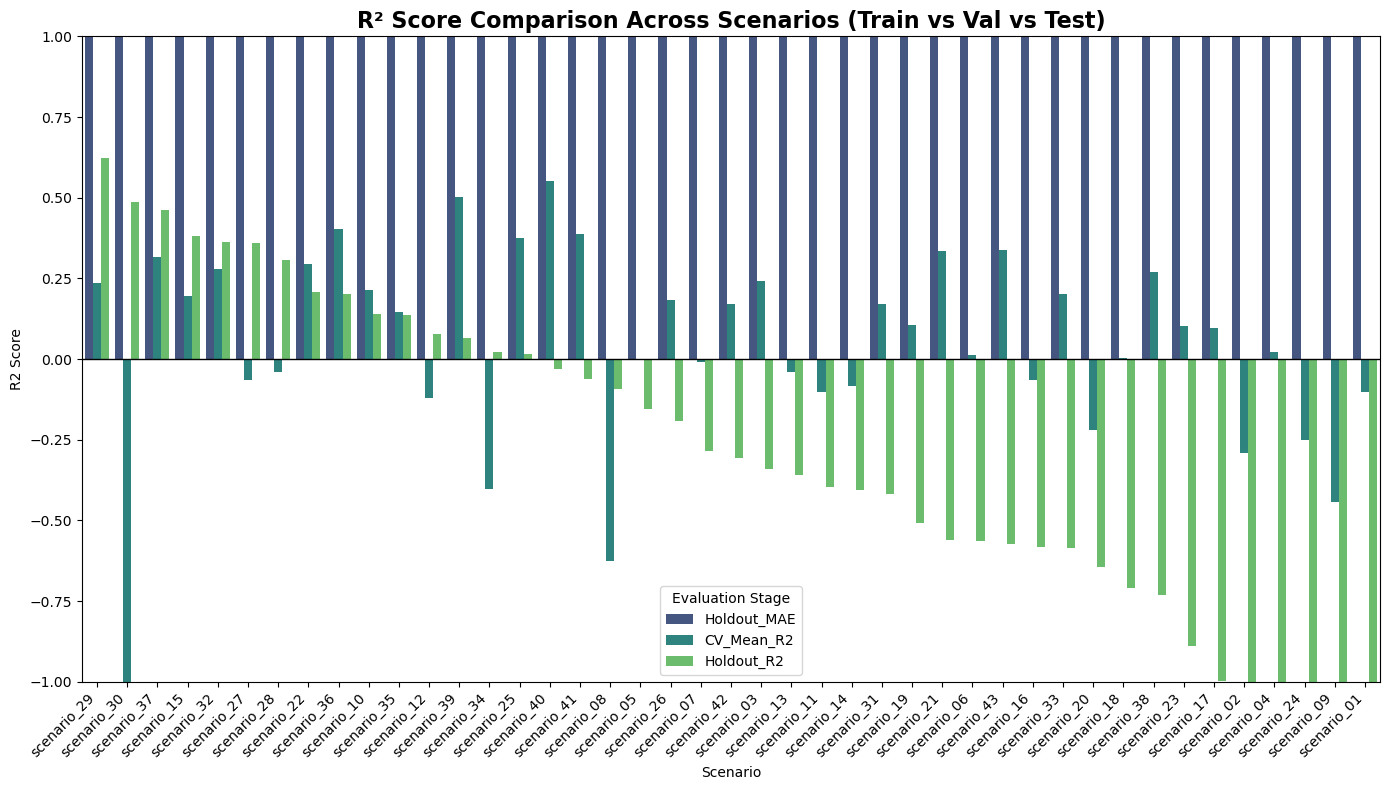

In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error)
import os
import random
import joblib
import shutil  # Required for deleting old models
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings


# ==========================================
# 1. SETUP & REPRODUCIBILITY
# ==========================================
def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.config.experimental.enable_op_determinism()

SEED = 42
seed_everything(SEED)
BASE_SAVE_DIR = "SOC_Hybrid_MViT-Qwen_Models_1x1"
PLOT_SAVE_DIR = "SOC_Hybrid_Visualizations_1x1"

if not os.path.exists(PLOT_SAVE_DIR):
    os.makedirs(PLOT_SAVE_DIR)

# ==========================================
# 2. CUSTOM LAYERS
# ==========================================

@keras.utils.register_keras_serializable()
class RMSNorm(layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon
    def build(self, input_shape):
        self.scale = self.add_weight(name='scale', shape=(input_shape[-1],), initializer='ones', trainable=True)
        super().build(input_shape)
    def call(self, x):
        mean_square = tf.reduce_mean(tf.square(x), axis=-1, keepdims=True)
        return x * tf.math.rsqrt(mean_square + self.epsilon) * self.scale
    def get_config(self):
        return {**super().get_config(), "epsilon": self.epsilon}

@keras.utils.register_keras_serializable()
class SwiGLU(layers.Layer):
    def __init__(self, hidden_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout_rate
    def build(self, input_shape):
        self.w_gate = layers.Dense(self.hidden_dim, use_bias=False)
        self.w_val = layers.Dense(self.hidden_dim, use_bias=False)
        self.w_out = layers.Dense(input_shape[-1], use_bias=False)
        self.dropout = layers.Dropout(self.dropout_rate)
    def call(self, x):
        return self.dropout(self.w_out(tf.nn.silu(self.w_gate(x)) * self.w_val(x)))
    def get_config(self):
        return {**super().get_config(), "hidden_dim": self.hidden_dim, "dropout_rate": self.dropout_rate}

@keras.utils.register_keras_serializable()
class RotaryEmbedding(layers.Layer):
    def __init__(self, dim, max_len=1024, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.max_len = max_len
    def build(self, input_shape):
        inv_freq = 1.0 / (10000 ** (tf.range(0, self.dim, 2, dtype=tf.float32) / self.dim))
        t = tf.range(self.max_len, dtype=tf.float32)
        freqs = tf.einsum('i,j->ij', t, inv_freq)
        self.cos_cached = tf.Variable(tf.cos(freqs), trainable=False, dtype=tf.float32)
        self.sin_cached = tf.Variable(tf.sin(freqs), trainable=False, dtype=tf.float32)
        super().build(input_shape)
    def call(self, x):
        seq_len = tf.shape(x)[1]
        cos, sin = self.cos_cached[:seq_len, :], self.sin_cached[:seq_len, :]
        x_rot, x_pass = x[..., :self.dim], x[..., self.dim:]
        x1, x2 = x_rot[..., :self.dim // 2], x_rot[..., self.dim // 2:]
        return tf.concat([x1 * cos - x2 * sin, x1 * sin + x2 * cos, x_pass], axis=-1)
    def get_config(self):
        return {**super().get_config(), "dim": self.dim, "max_len": self.max_len}

# ==========================================
# 3. HYBRID MODEL BUILDER
# ==========================================

def build_hybrid_mvit_qwen(input_dim, num_patches=8, embed_dim=128, dropout=0.1):
    inputs = layers.Input(shape=(input_dim,), name="input_features")

    # --- Branch A: MViT ---
    x_mvit = layers.Reshape((num_patches, embed_dim))(layers.Dense(num_patches * embed_dim)(inputs))
    pos_emb = layers.Embedding(input_dim=num_patches, output_dim=embed_dim)(tf.range(0, num_patches))
    x_mvit = x_mvit + pos_emb

    for _ in range(2):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x_mvit)
        x_mvit = layers.Add()([x_mvit, layers.MultiHeadAttention(num_heads=4, key_dim=embed_dim)(x1, x1)])
        x2 = layers.LayerNormalization(epsilon=1e-6)(x_mvit)
        mlp = layers.Dropout(dropout)(layers.Dense(embed_dim*2, activation="gelu")(x2))
        x_mvit = layers.Add()([x_mvit, layers.Dense(embed_dim)(mlp)])
    out_mvit = layers.LayerNormalization()(layers.GlobalAveragePooling1D()(x_mvit))

    # --- Branch B: Qwen ---
    x_qwen = layers.Dropout(dropout)(layers.Reshape((num_patches, embed_dim))(layers.Dense(num_patches * embed_dim)(inputs)))
    rope = RotaryEmbedding(embed_dim // 4)

    for _ in range(2):
        x_norm = RMSNorm()(x_qwen)
        x_rot = rope(x_norm)
        x_qwen = layers.Add()([x_qwen, layers.MultiHeadAttention(num_heads=4, key_dim=embed_dim, dropout=dropout)(x_rot, x_rot)])
        x_norm = RMSNorm()(x_qwen)
        x_qwen = layers.Add()([x_qwen, SwiGLU(hidden_dim=embed_dim*2, dropout_rate=dropout)(x_norm)])
    out_qwen = layers.GlobalAveragePooling1D()(RMSNorm()(x_qwen))

    # --- Fusion ---
    gate = layers.Dense(embed_dim, activation='sigmoid')(layers.Concatenate()([out_mvit, out_qwen]))
    fused = layers.Add()([layers.Multiply()([out_mvit, gate]), layers.Multiply()([out_qwen, 1 - gate])])

    outputs = layers.Dense(1, activation='linear')(layers.Dropout(0.1)(layers.Dense(64, activation='relu')(fused)))
    return keras.Model(inputs=inputs, outputs=outputs, name="Hybrid_MViT_Qwen")

# ==========================================
# 4. UTILS & TOP-5 MANAGER
# ==========================================

class TopModelManager:
    """Manages the Top-5 models on disk based on RMSE (asc) and R2 (desc)."""
    def __init__(self, save_dir=BASE_SAVE_DIR, max_models=5):
        self.save_dir = save_dir
        self.max_models = max_models
        self.top_models = []
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

    def process_candidate(self, model, scaler, scenario, rmse, r2, cv_r2):
        candidate = {
            'rmse': rmse, 'r2': r2, 'scenario': scenario, 'cv_r2': cv_r2,
            'folder_name': f"{scenario}_RMSE_{rmse:.4f}_R2_{r2:.4f}_CV-R2_{cv_r2:.4f}"
        }
        self.top_models.sort(key=lambda x: (x['rmse'], -x['r2']))

        should_save = False
        if len(self.top_models) < self.max_models:
            should_save = True
        else:
            worst_best = self.top_models[-1]
            if (rmse < worst_best['rmse']) or (rmse == worst_best['rmse'] and r2 > worst_best['r2']):
                should_save = True

        if should_save:
            full_path = os.path.join(self.save_dir, candidate['folder_name'])
            os.makedirs(full_path, exist_ok=True)
            model.save(os.path.join(full_path, "model.keras"))
            joblib.dump(scaler, os.path.join(full_path, "scaler.pkl"))
            print(f"   ✅ [SAVED] Top-5 Candidate: {full_path}")
            
            candidate['path'] = full_path
            self.top_models.append(candidate)
            self.top_models.sort(key=lambda x: (x['rmse'], -x['r2']))
            
            if len(self.top_models) > self.max_models:
                to_remove = self.top_models.pop()
                print(f"   🗑️ [PRUNING] Removing displaced model: {to_remove['folder_name']}")
                if os.path.exists(to_remove['path']):
                    shutil.rmtree(to_remove['path'])
        else:
            print(f"   [SKIP] Model did not qualify for Top-5.")

def predict_from_loaded(scenario_folder_name, new_data, feature_cols, base_dir=BASE_SAVE_DIR):
    path = os.path.join(base_dir, scenario_folder_name)
    model_path = os.path.join(path, "model.keras")
    scaler_path = os.path.join(path, "scaler.pkl")
    
    if not os.path.exists(model_path): return None

    custom_objects = {'RMSNorm': RMSNorm, 'SwiGLU': SwiGLU, 'RotaryEmbedding': RotaryEmbedding}
    model = keras.models.load_model(model_path, custom_objects=custom_objects)
    scaler = joblib.load(scaler_path)

    if isinstance(new_data, pd.DataFrame):
        X = new_data[feature_cols].values
    else:
        X = new_data 

    X_scaled = scaler.transform(X)
    y_pred = np.expm1(model.predict(X_scaled, verbose=0).flatten())
    return np.maximum(y_pred, 0)

# ==========================================
# 5. TRAINING HELPERS & VISUALIZATIONS
# ==========================================

def clip_outliers(X_train, X_test=None, lower_percentile=1, upper_percentile=99):
    X_train_clipped = X_train.copy()
    X_test_clipped = X_test.copy() if X_test is not None else None
    
    for col in X_train.columns:
        lower = X_train[col].quantile(lower_percentile / 100)
        upper = X_train[col].quantile(upper_percentile / 100)
        
        X_train_clipped[col] = X_train_clipped[col].clip(lower, upper)
        if X_test_clipped is not None:
            X_test_clipped[col] = X_test_clipped[col].clip(lower, upper)
            
    return X_train_clipped, X_test_clipped

def get_lr_schedule(total_steps, lr_max=0.001):
    return keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=lr_max, decay_steps=total_steps, alpha=0.01
    )

def plot_scenario_performance(scenario, y_train, pred_train, y_test, pred_test, history):
    """Generates and saves full parity plots, residual plots, and training history."""
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f"Model Performance: {scenario}", fontsize=18, weight='bold')
    
    # 1. Parity Plot: Train vs Pred
    ax1 = plt.subplot(2, 3, 1)
    sns.scatterplot(x=y_train, y=pred_train, alpha=0.5, color='blue', ax=ax1)
    ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2)
    ax1.set_title(f"Train: Actual vs Predicted (R²={r2_score(y_train, pred_train):.3f})")
    ax1.set_xlabel("Actual SOC")
    ax1.set_ylabel("Predicted SOC")
    
    # 2. Parity Plot: Test vs Pred
    ax2 = plt.subplot(2, 3, 2)
    sns.scatterplot(x=y_test, y=pred_test, alpha=0.5, color='orange', ax=ax2)
    ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    ax2.set_title(f"Test: Actual vs Predicted (R²={r2_score(y_test, pred_test):.3f})")
    ax2.set_xlabel("Actual SOC")
    ax2.set_ylabel("Predicted SOC")

    # 3. Training History (Loss)
    ax3 = plt.subplot(2, 3, 3)
    ax3.plot(history.history['loss'], label='Train Huber Loss', color='blue')
    # Validation loss isn't logged in final training loop by default unless we pass validation data. 
    # Left as strictly training loss for the final epoch curve.
    ax3.set_title("Final Model Training History")
    ax3.set_xlabel("Epochs")
    ax3.set_ylabel("Loss")
    ax3.legend()

    # 4. Residuals: Train
    ax4 = plt.subplot(2, 3, 4)
    train_residuals = y_train - pred_train
    sns.histplot(train_residuals, kde=True, color='blue', ax=ax4)
    ax4.axvline(0, color='k', linestyle='--')
    ax4.set_title("Train Residuals Distribution")

    # 5. Residuals: Test
    ax5 = plt.subplot(2, 3, 5)
    test_residuals = y_test - pred_test
    sns.histplot(test_residuals, kde=True, color='orange', ax=ax5)
    ax5.axvline(0, color='k', linestyle='--')
    ax5.set_title("Test Residuals Distribution")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    plot_path = os.path.join(PLOT_SAVE_DIR, f"{scenario}_performance_plots.png")
    plt.savefig(plot_path, dpi=300)
    plt.close()
    print(f"   📊 [SAVED] Scenario Plot: {plot_path}")


# ==========================================
# 5.5 SHAP EXPLAINABILITY VISUALIZATIONS
# ==========================================

def generate_shap_visualizations(model, scaler, X_train_raw, X_test_raw, feature_cols, scenario_name, save_dir=PLOT_SAVE_DIR):
    """
    Generates comprehensive SHAP plots (Bar, Beeswarm, Waterfall) for the custom hybrid model.
    Uses KernelExplainer to bypass gradient graph issues with custom TF layers.
    """
    print(f"\n   🧠 Generating SHAP visualizations for {scenario_name}...")
    
    # Ensure SHAP save directory exists
    shap_dir = os.path.join(save_dir, f"{scenario_name}_SHAP")
    os.makedirs(shap_dir, exist_ok=True)

    # 1. Prepare Data (DYNAMIC SIZING FIX)
    n_train_samples = len(X_train_raw)
    if n_train_samples > 50:
        # If we have a lot of data, cluster it down to 50 for speed
        X_train_summary = shap.kmeans(X_train_raw[feature_cols], 50) 
    else:
        # If the dataset is small, just use the raw data as the background
        X_train_summary = X_train_raw[feature_cols]
    
    # Subsample test data (up to 100 rows) for the explanation
    test_sample_size = min(100, len(X_test_raw))
    # If the test set is exactly the size we need or smaller, no need to randomly sample
    if len(X_test_raw) <= test_sample_size:
        X_test_sample = X_test_raw[feature_cols]
    else:
        X_test_sample = X_test_raw[feature_cols].sample(n=test_sample_size, random_state=SEED)
    
    # # 2. Define Prediction Wrapper
    # def predict_wrapper(X_array):
    #     if len(X_array.shape) == 1:
    #         X_array = X_array.reshape(1, -1)
    #     X_scaled = scaler.transform(X_array)
    #     return model.predict(X_scaled, verbose=0).flatten()
    
    # 2. Define Prediction Wrapper
    def predict_wrapper(X_array):
        # Convert to 2D if SHAP passes a 1D array
        if len(X_array.shape) == 1:
            X_array = X_array.reshape(1, -1)
            
        # --- THE FIX: Convert the raw array back into a DataFrame with column names ---
        X_df = pd.DataFrame(X_array, columns=feature_cols)
        
        # Now the scaler will recognize the feature names!
        X_scaled = scaler.transform(X_df)
        
        return model.predict(X_scaled, verbose=0).flatten()
        
    # 3. Initialize Explainer & Calculate Values
    explainer = shap.KernelExplainer(predict_wrapper, X_train_summary)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # Calculate SHAP values
        shap_values_raw = explainer.shap_values(X_test_sample, nsamples=200)
        
    # Handle SHAP return type inconsistencies
    shap_values = shap_values_raw[0] if isinstance(shap_values_raw, list) else shap_values_raw

    # Create an Explanation object
    exp = shap.Explanation(values=shap_values, 
                           base_values=explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value, 
                           data=X_test_sample.values, 
                           feature_names=feature_cols)

    # --- Plot 1: Summary Bar Plot ---
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
    plt.title(f"SHAP Global Feature Importance - {scenario_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(shap_dir, f"{scenario_name}_shap_bar.png"), dpi=300, bbox_inches='tight')
    plt.close()

    # --- Plot 2: Summary Beeswarm Plot ---
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_sample, show=False)
    plt.title(f"SHAP Beeswarm Summary - {scenario_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(shap_dir, f"{scenario_name}_shap_beeswarm.png"), dpi=300, bbox_inches='tight')
    plt.close()

    # --- Plot 3: Waterfall Plot ---
    plt.figure(figsize=(10, 8))
    shap.waterfall_plot(exp[0], show=False)
    plt.title(f"SHAP Waterfall (Local Prediction Sample 0) - {scenario_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(shap_dir, f"{scenario_name}_shap_waterfall.png"), dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"   ✅ [SAVED] SHAP visualizations saved to: {shap_dir}")

# ==========================================
# 6. MAIN EXECUTION
# ==========================================

# Assuming 'scenarios', 'X_train', 'y_train', 'X_test', 'y_test' exist
if 'scenarios' not in locals():
    print("WARNING: 'scenarios' dictionary not defined.")
    scenarios = {} 

hybrid_results = []
top_saver = TopModelManager(max_models=5)
print("Starting Hybrid Model Training (Top-5 Saved)...")

kf = KFold(n_splits=3, shuffle=True, random_state=SEED)

for scenario_name, feature_cols in scenarios.items():
    feature_cols = list(set(feature_cols))
    valid_cols = [c for c in feature_cols if c in X_train.columns]
    
    if not valid_cols: continue

    X_train_sub = X_train[valid_cols].copy()
    X_test_sub = X_test[valid_cols].copy() 
    
    train_indices = X_train_sub.dropna().index.intersection(y_train.dropna().index)
    X = X_train_sub.loc[train_indices].reset_index(drop=True)
    y = y_train.loc[train_indices].reset_index(drop=True)

    if len(X) < 10: continue

    print(f"\n--- Scenario: {scenario_name} (Feats: {len(valid_cols)}, Samples: {len(X)}) ---")

    fold_train_r2, fold_val_r2, fold_rmse = [], [], []

    # --- CROSS VALIDATION LOOP ---
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_tr_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        X_tr_clip, X_val_clip = clip_outliers(X_tr_fold, X_val_fold)
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr_clip)
        X_val_sc = scaler.transform(X_val_clip)

        y_tr_log = np.log1p(y_tr_fold)
        y_val_log = np.log1p(y_val_fold)

        input_dim = X_tr_sc.shape[1]
        n_patches = 8 if input_dim > 15 else 4
        steps_per_epoch = max(1, len(X_tr_sc) // 32)
        total_steps = max(1, 1500 * steps_per_epoch)
        
        model = build_hybrid_mvit_qwen(input_dim, num_patches=n_patches, embed_dim=128, dropout=0.15)
        model.compile(
            loss=keras.losses.Huber(delta=1.0), 
            optimizer=keras.optimizers.AdamW(learning_rate=get_lr_schedule(total_steps), weight_decay=0.02),
            metrics=['mae']
        )

        model.fit(
            X_tr_sc, y_tr_log,
            validation_data=(X_val_sc, y_val_log), 
            epochs= 1500, # r2 0.36            
            batch_size=32,
            callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
            verbose=0
        )

        # Eval Train
        y_tr_pred = np.maximum(np.expm1(model.predict(X_tr_sc, verbose=0).flatten()), 0)
        fold_train_r2.append(r2_score(y_tr_fold, y_tr_pred))

        # Eval Val
        y_val_pred = np.maximum(np.expm1(model.predict(X_val_sc, verbose=0).flatten()), 0)
        fold_val_r2.append(r2_score(y_val_fold, y_val_pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_val_fold, y_val_pred)))
        
        print(f"   Fold {fold+1} | Train R2: {fold_train_r2[-1]:.4f} | Val R2: {fold_val_r2[-1]:.4f}")

    # --- FINAL FULL TRAINING & TOP-5 SAVING ---
    print(f"   >> Retraining full model for evaluation...")
    X_full_clip, X_test_clip = clip_outliers(X, X_test_sub)
    final_scaler = StandardScaler()
    X_full_sc = final_scaler.fit_transform(X_full_clip)
    X_test_sc = final_scaler.transform(X_test_clip) 
    y_full_log = np.log1p(y)

    final_model = build_hybrid_mvit_qwen(input_dim, num_patches=n_patches, embed_dim=128)
    steps_per_epoch_final = max(1, len(X_full_sc) // 32)
    total_steps_final = max(1, 2000 * steps_per_epoch_final)
    
    final_model.compile(
        loss=keras.losses.Huber(delta=1.0),
        optimizer=keras.optimizers.AdamW(learning_rate=get_lr_schedule(total_steps_final)),
        metrics=['mae']
    )

    history = final_model.fit(X_full_sc, y_full_log, 
                              epochs= 4200, #r2 0.61 
                              batch_size=32, verbose=0)

    # Predict on Train & Holdout Test
    # y_full_pred = np.maximum(np.expm1(final_model.predict(X_full_sc, verbose=0).flatten()), 0)
    y_pred_h = np.maximum(np.expm1(final_model.predict(X_test_sc, verbose=0).flatten()), 0)
 
    # Calculate Metrics
    r2_final = r2_score(y_test, y_pred_h)
    rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_h))
    mae_final = mean_absolute_error(y_test, y_pred_h)
    mape_final = mean_absolute_percentage_error(y_test, y_pred_h)
    cv_mean_r2 = np.mean(fold_val_r2)
    cv_min_r2 = np.min(fold_val_r2)
    cv_max_r2 = np.max(fold_val_r2)

    # --- TOP-5 SAVER LOGIC ---
    # Instead of unconditional saving, we let the manager decide
    top_saver.process_candidate(
        final_model, final_scaler, scenario_name, 
        rmse_final, r2_final, cv_mean_r2
    )

    hybrid_results.append({
        'Scenario': scenario_name,
        'CV_Mean_R2': cv_mean_r2,
        'CV_Min_R2': cv_min_r2,
        'CV_Max_R2': cv_max_r2,
        'CV_Std_R2': np.std(fold_val_r2),
        'CV_Mean_RMSE': np.mean(fold_rmse),
        'Holdout_R2': r2_final,
        'Holdout_RMSE': rmse_final,
        'Holdout_MAE': mae_final,
        'Holdout_MAPE': mape_final
    })

    print(f"   [Result] CV_Mean_R2: {cv_mean_r2:.4f} | Holdout_R2: {r2_final:.4f} | Holdout_RMSE: {rmse_final:.4f}")


    # ==========================================
    # ---> ADD THE SHAP CALL HERE <---
    # ==========================================
    # We pass the unclipped/unscaled data because our wrapper handles the scaling,
    # ensuring the SHAP plots show the actual real-world feature values on the axes.
    generate_shap_visualizations(
        model=final_model, 
        scaler=final_scaler, 
        X_train_raw=X, 
        X_test_raw=X_test_sub, 
        feature_cols=valid_cols, 
        scenario_name=scenario_name
    )
    
# ==========================================
# 7. RESULTS & OVERALL VISUALIZATION
# ==========================================
if hybrid_results:
    results_df = pd.DataFrame(hybrid_results).sort_values(by='Holdout_R2', ascending=False)
    print("\n" + "="*80)
    print("HYBRID MViT + QWEN RESULTS (WITH TRAIN/VAL/TEST R2)")
    print("="*80)
    print(results_df[['Scenario', 'CV_Mean_R2', 'Holdout_R2', 'Holdout_RMSE', 'Holdout_MAE', 'Holdout_MAPE']])
    results_df.to_csv('SOC_Hybrid_MViT-QWEN_1x1_Results_Local.csv', index=False)

    # Plot Overall Comparison Bar Chart
    plt.figure(figsize=(14, 8))
    
    plot_data = results_df.melt(
        id_vars=['Scenario'], 
        value_vars=['Holdout_MAE', 'CV_Mean_R2', 'Holdout_R2'],
        var_name='Metric', value_name='R2 Score'
    )
    
    sns.barplot(data=plot_data, x='Scenario', y='R2 Score', hue='Metric', palette='viridis')
    plt.title("R² Score Comparison Across Scenarios (Train vs Val vs Test)", fontsize=16, weight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(max(-1, plot_data['R2 Score'].min() - 0.1), 1.0) # Scale appropriately
    plt.axhline(0, color='black', linewidth=1)
    plt.legend(title='Evaluation Stage')
    plt.tight_layout()
    
    summary_plot_path = os.path.join(PLOT_SAVE_DIR, "Overall_R2_Comparison.png")
    plt.savefig(summary_plot_path, dpi=300)
    print(f"\n   📊 [SAVED] Summary Bar Chart: {summary_plot_path}")

## Test-2 (R2 = 0.60 ; CV-R2= 0.20 )
Train $R^2$, Val $R^2$ (via Cross-Validation), and Test $R^2$ (Holdout). 

In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error)
import os
import random
import joblib
import shutil  # Required for deleting old models
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings


# ==========================================
# 1. SETUP & REPRODUCIBILITY
# ==========================================
def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.config.experimental.enable_op_determinism()

SEED = 42
seed_everything(SEED)
BASE_SAVE_DIR = "SOC_Hybrid_MViT-Qwen_Models_1x1"
PLOT_SAVE_DIR = "SOC_Hybrid_Visualizations_1x1"

if not os.path.exists(PLOT_SAVE_DIR):
    os.makedirs(PLOT_SAVE_DIR)

# ==========================================
# 2. CUSTOM LAYERS
# ==========================================

@keras.utils.register_keras_serializable()
class RMSNorm(layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon
    def build(self, input_shape):
        self.scale = self.add_weight(name='scale', shape=(input_shape[-1],), initializer='ones', trainable=True)
        super().build(input_shape)
    def call(self, x):
        mean_square = tf.reduce_mean(tf.square(x), axis=-1, keepdims=True)
        return x * tf.math.rsqrt(mean_square + self.epsilon) * self.scale
    def get_config(self):
        return {**super().get_config(), "epsilon": self.epsilon}

@keras.utils.register_keras_serializable()
class SwiGLU(layers.Layer):
    def __init__(self, hidden_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout_rate
    def build(self, input_shape):
        self.w_gate = layers.Dense(self.hidden_dim, use_bias=False)
        self.w_val = layers.Dense(self.hidden_dim, use_bias=False)
        self.w_out = layers.Dense(input_shape[-1], use_bias=False)
        self.dropout = layers.Dropout(self.dropout_rate)
    def call(self, x):
        return self.dropout(self.w_out(tf.nn.silu(self.w_gate(x)) * self.w_val(x)))
    def get_config(self):
        return {**super().get_config(), "hidden_dim": self.hidden_dim, "dropout_rate": self.dropout_rate}

@keras.utils.register_keras_serializable()
class RotaryEmbedding(layers.Layer):
    def __init__(self, dim, max_len=1024, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.max_len = max_len
    def build(self, input_shape):
        inv_freq = 1.0 / (10000 ** (tf.range(0, self.dim, 2, dtype=tf.float32) / self.dim))
        t = tf.range(self.max_len, dtype=tf.float32)
        freqs = tf.einsum('i,j->ij', t, inv_freq)
        self.cos_cached = tf.Variable(tf.cos(freqs), trainable=False, dtype=tf.float32)
        self.sin_cached = tf.Variable(tf.sin(freqs), trainable=False, dtype=tf.float32)
        super().build(input_shape)
    def call(self, x):
        seq_len = tf.shape(x)[1]
        cos, sin = self.cos_cached[:seq_len, :], self.sin_cached[:seq_len, :]
        x_rot, x_pass = x[..., :self.dim], x[..., self.dim:]
        x1, x2 = x_rot[..., :self.dim // 2], x_rot[..., self.dim // 2:]
        return tf.concat([x1 * cos - x2 * sin, x1 * sin + x2 * cos, x_pass], axis=-1)
    def get_config(self):
        return {**super().get_config(), "dim": self.dim, "max_len": self.max_len}

# ==========================================
# 3. HYBRID MODEL BUILDER
# ==========================================

def build_hybrid_mvit_qwen(input_dim, num_patches=8, embed_dim=128, dropout=0.1):
    inputs = layers.Input(shape=(input_dim,), name="input_features")

    # --- Branch A: MViT ---
    x_mvit = layers.Reshape((num_patches, embed_dim))(layers.Dense(num_patches * embed_dim)(inputs))
    pos_emb = layers.Embedding(input_dim=num_patches, output_dim=embed_dim)(tf.range(0, num_patches))
    x_mvit = x_mvit + pos_emb

    for _ in range(2):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x_mvit)
        x_mvit = layers.Add()([x_mvit, layers.MultiHeadAttention(num_heads=4, key_dim=embed_dim)(x1, x1)])
        x2 = layers.LayerNormalization(epsilon=1e-6)(x_mvit)
        mlp = layers.Dropout(dropout)(layers.Dense(embed_dim*2, activation="gelu")(x2))
        x_mvit = layers.Add()([x_mvit, layers.Dense(embed_dim)(mlp)])
    out_mvit = layers.LayerNormalization()(layers.GlobalAveragePooling1D()(x_mvit))

    # --- Branch B: Qwen ---
    x_qwen = layers.Dropout(dropout)(layers.Reshape((num_patches, embed_dim))(layers.Dense(num_patches * embed_dim)(inputs)))
    rope = RotaryEmbedding(embed_dim // 4)

    for _ in range(2):
        x_norm = RMSNorm()(x_qwen)
        x_rot = rope(x_norm)
        x_qwen = layers.Add()([x_qwen, layers.MultiHeadAttention(num_heads=4, key_dim=embed_dim, dropout=dropout)(x_rot, x_rot)])
        x_norm = RMSNorm()(x_qwen)
        x_qwen = layers.Add()([x_qwen, SwiGLU(hidden_dim=embed_dim*2, dropout_rate=dropout)(x_norm)])
    out_qwen = layers.GlobalAveragePooling1D()(RMSNorm()(x_qwen))

    # --- Fusion ---
    gate = layers.Dense(embed_dim, activation='sigmoid')(layers.Concatenate()([out_mvit, out_qwen]))
    fused = layers.Add()([layers.Multiply()([out_mvit, gate]), layers.Multiply()([out_qwen, 1 - gate])])

    outputs = layers.Dense(1, activation='linear')(layers.Dropout(0.1)(layers.Dense(64, activation='relu')(fused)))
    return keras.Model(inputs=inputs, outputs=outputs, name="Hybrid_MViT_Qwen")

# ==========================================
# 4. UTILS & TOP-5 MANAGER
# ==========================================

class TopModelManager:
    """Manages the Top-5 models on disk based on RMSE (asc) and R2 (desc)."""
    def __init__(self, save_dir=BASE_SAVE_DIR, max_models=5):
        self.save_dir = save_dir
        self.max_models = max_models
        self.top_models = []
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

    def process_candidate(self, model, scaler, scenario, rmse, r2, cv_r2):
        candidate = {
            'rmse': rmse, 'r2': r2, 'scenario': scenario, 'cv_r2': cv_r2,
            'folder_name': f"{scenario}_RMSE_{rmse:.4f}_R2_{r2:.4f}_CV-R2_{cv_r2:.4f}"
        }
        self.top_models.sort(key=lambda x: (x['rmse'], -x['r2']))

        should_save = False
        if len(self.top_models) < self.max_models:
            should_save = True
        else:
            worst_best = self.top_models[-1]
            if (rmse < worst_best['rmse']) or (rmse == worst_best['rmse'] and r2 > worst_best['r2']):
                should_save = True

        if should_save:
            full_path = os.path.join(self.save_dir, candidate['folder_name'])
            os.makedirs(full_path, exist_ok=True)
            model.save(os.path.join(full_path, "model.keras"))
            joblib.dump(scaler, os.path.join(full_path, "scaler.pkl"))
            print(f"   ✅ [SAVED] Top-5 Candidate: {full_path}")
            
            candidate['path'] = full_path
            self.top_models.append(candidate)
            self.top_models.sort(key=lambda x: (x['rmse'], -x['r2']))
            
            if len(self.top_models) > self.max_models:
                to_remove = self.top_models.pop()
                print(f"   🗑️ [PRUNING] Removing displaced model: {to_remove['folder_name']}")
                if os.path.exists(to_remove['path']):
                    shutil.rmtree(to_remove['path'])
        else:
            print(f"   [SKIP] Model did not qualify for Top-5.")

def predict_from_loaded(scenario_folder_name, new_data, feature_cols, base_dir=BASE_SAVE_DIR):
    path = os.path.join(base_dir, scenario_folder_name)
    model_path = os.path.join(path, "model.keras")
    scaler_path = os.path.join(path, "scaler.pkl")
    
    if not os.path.exists(model_path): return None

    custom_objects = {'RMSNorm': RMSNorm, 'SwiGLU': SwiGLU, 'RotaryEmbedding': RotaryEmbedding}
    model = keras.models.load_model(model_path, custom_objects=custom_objects)
    scaler = joblib.load(scaler_path)

    if isinstance(new_data, pd.DataFrame):
        X = new_data[feature_cols].values
    else:
        X = new_data 

    X_scaled = scaler.transform(X)
    y_pred = np.expm1(model.predict(X_scaled, verbose=0).flatten())
    return np.maximum(y_pred, 0)

# ==========================================
# 5. TRAINING HELPERS & VISUALIZATIONS
# ==========================================

def clip_outliers(X_train, X_test=None, lower_percentile=1, upper_percentile=99):
    X_train_clipped = X_train.copy()
    X_test_clipped = X_test.copy() if X_test is not None else None
    
    for col in X_train.columns:
        lower = X_train[col].quantile(lower_percentile / 100)
        upper = X_train[col].quantile(upper_percentile / 100)
        
        X_train_clipped[col] = X_train_clipped[col].clip(lower, upper)
        if X_test_clipped is not None:
            X_test_clipped[col] = X_test_clipped[col].clip(lower, upper)
            
    return X_train_clipped, X_test_clipped

def get_lr_schedule(total_steps, lr_max=0.001):
    return keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=lr_max, decay_steps=total_steps, alpha=0.01
    )

def plot_scenario_performance(scenario, y_train, pred_train, y_test, pred_test, history):
    """Generates and saves full parity plots, residual plots, and training history."""
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f"Model Performance: {scenario}", fontsize=18, weight='bold')
    
    # 1. Parity Plot: Train vs Pred
    ax1 = plt.subplot(2, 3, 1)
    sns.scatterplot(x=y_train, y=pred_train, alpha=0.5, color='blue', ax=ax1)
    ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2)
    ax1.set_title(f"Train: Actual vs Predicted (R²={r2_score(y_train, pred_train):.3f})")
    ax1.set_xlabel("Actual SOC")
    ax1.set_ylabel("Predicted SOC")
    
    # 2. Parity Plot: Test vs Pred
    ax2 = plt.subplot(2, 3, 2)
    sns.scatterplot(x=y_test, y=pred_test, alpha=0.5, color='orange', ax=ax2)
    ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    ax2.set_title(f"Test: Actual vs Predicted (R²={r2_score(y_test, pred_test):.3f})")
    ax2.set_xlabel("Actual SOC")
    ax2.set_ylabel("Predicted SOC")

    # 3. Training History (Loss)
    ax3 = plt.subplot(2, 3, 3)
    ax3.plot(history.history['loss'], label='Train Huber Loss', color='blue')
    # Validation loss isn't logged in final training loop by default unless we pass validation data. 
    # Left as strictly training loss for the final epoch curve.
    ax3.set_title("Final Model Training History")
    ax3.set_xlabel("Epochs")
    ax3.set_ylabel("Loss")
    ax3.legend()

    # 4. Residuals: Train
    ax4 = plt.subplot(2, 3, 4)
    train_residuals = y_train - pred_train
    sns.histplot(train_residuals, kde=True, color='blue', ax=ax4)
    ax4.axvline(0, color='k', linestyle='--')
    ax4.set_title("Train Residuals Distribution")

    # 5. Residuals: Test
    ax5 = plt.subplot(2, 3, 5)
    test_residuals = y_test - pred_test
    sns.histplot(test_residuals, kde=True, color='orange', ax=ax5)
    ax5.axvline(0, color='k', linestyle='--')
    ax5.set_title("Test Residuals Distribution")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    plot_path = os.path.join(PLOT_SAVE_DIR, f"{scenario}_performance_plots.png")
    plt.savefig(plot_path, dpi=300)
    plt.close()
    print(f"   📊 [SAVED] Scenario Plot: {plot_path}")


# ==========================================
# 5.5 SHAP EXPLAINABILITY VISUALIZATIONS
# ==========================================

def generate_shap_visualizations(model, scaler, X_train_raw, X_test_raw, feature_cols, scenario_name, save_dir=PLOT_SAVE_DIR):
    """
    Generates comprehensive SHAP plots (Bar, Beeswarm, Waterfall) for the custom hybrid model.
    Uses KernelExplainer to bypass gradient graph issues with custom TF layers.
    """
    print(f"\n   🧠 Generating SHAP visualizations for {scenario_name}...")
    
    # Ensure SHAP save directory exists
    shap_dir = os.path.join(save_dir, f"{scenario_name}_SHAP")
    os.makedirs(shap_dir, exist_ok=True)

    # 1. Prepare Data (DYNAMIC SIZING FIX)
    n_train_samples = len(X_train_raw)
    if n_train_samples > 50:
        # If we have a lot of data, cluster it down to 50 for speed
        X_train_summary = shap.kmeans(X_train_raw[feature_cols], 50) 
    else:
        # If the dataset is small, just use the raw data as the background
        X_train_summary = X_train_raw[feature_cols]
    
    # Subsample test data (up to 100 rows) for the explanation
    test_sample_size = min(100, len(X_test_raw))
    # If the test set is exactly the size we need or smaller, no need to randomly sample
    if len(X_test_raw) <= test_sample_size:
        X_test_sample = X_test_raw[feature_cols]
    else:
        X_test_sample = X_test_raw[feature_cols].sample(n=test_sample_size, random_state=SEED)
    
    # # 2. Define Prediction Wrapper
    # def predict_wrapper(X_array):
    #     if len(X_array.shape) == 1:
    #         X_array = X_array.reshape(1, -1)
    #     X_scaled = scaler.transform(X_array)
    #     return model.predict(X_scaled, verbose=0).flatten()
    
    # 2. Define Prediction Wrapper
    def predict_wrapper(X_array):
        # Convert to 2D if SHAP passes a 1D array
        if len(X_array.shape) == 1:
            X_array = X_array.reshape(1, -1)
            
        # --- THE FIX: Convert the raw array back into a DataFrame with column names ---
        X_df = pd.DataFrame(X_array, columns=feature_cols)
        
        # Now the scaler will recognize the feature names!
        X_scaled = scaler.transform(X_df)
        
        return model.predict(X_scaled, verbose=0).flatten()
        
    # 3. Initialize Explainer & Calculate Values
    explainer = shap.KernelExplainer(predict_wrapper, X_train_summary)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # Calculate SHAP values
        shap_values_raw = explainer.shap_values(X_test_sample, nsamples=200)
        
    # Handle SHAP return type inconsistencies
    shap_values = shap_values_raw[0] if isinstance(shap_values_raw, list) else shap_values_raw

    # Create an Explanation object
    exp = shap.Explanation(values=shap_values, 
                           base_values=explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value, 
                           data=X_test_sample.values, 
                           feature_names=feature_cols)

    # --- Plot 1: Summary Bar Plot ---
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
    plt.title(f"SHAP Global Feature Importance - {scenario_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(shap_dir, f"{scenario_name}_shap_bar.png"), dpi=300, bbox_inches='tight')
    plt.close()

    # --- Plot 2: Summary Beeswarm Plot ---
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_sample, show=False)
    plt.title(f"SHAP Beeswarm Summary - {scenario_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(shap_dir, f"{scenario_name}_shap_beeswarm.png"), dpi=300, bbox_inches='tight')
    plt.close()

    # --- Plot 3: Waterfall Plot ---
    plt.figure(figsize=(10, 8))
    shap.waterfall_plot(exp[0], show=False)
    plt.title(f"SHAP Waterfall (Local Prediction Sample 0) - {scenario_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(shap_dir, f"{scenario_name}_shap_waterfall.png"), dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"   ✅ [SAVED] SHAP visualizations saved to: {shap_dir}")

# ==========================================
# 6. MAIN EXECUTION
# ==========================================

# Assuming 'scenarios', 'X_train', 'y_train', 'X_test', 'y_test' exist
if 'scenarios' not in locals():
    print("WARNING: 'scenarios' dictionary not defined.")
    scenarios = {} 

hybrid_results = []
top_saver = TopModelManager(max_models=5)
print("Starting Hybrid Model Training (Top-5 Saved)...")

kf = KFold(n_splits=3, shuffle=True, random_state=SEED)

for scenario_name, feature_cols in scenarios.items():
    feature_cols = list(set(feature_cols))
    valid_cols = [c for c in feature_cols if c in X_train.columns]
    
    if not valid_cols: continue

    X_train_sub = X_train[valid_cols].copy()
    X_test_sub = X_test[valid_cols].copy() 
    
    train_indices = X_train_sub.dropna().index.intersection(y_train.dropna().index)
    X = X_train_sub.loc[train_indices].reset_index(drop=True)
    y = y_train.loc[train_indices].reset_index(drop=True)

    if len(X) < 10: continue

    print(f"\n--- Scenario: {scenario_name} (Feats: {len(valid_cols)}, Samples: {len(X)}) ---")

    fold_train_r2, fold_val_r2, fold_rmse = [], [], []

    # --- CROSS VALIDATION LOOP ---
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_tr_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        X_tr_clip, X_val_clip = clip_outliers(X_tr_fold, X_val_fold)
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr_clip)
        X_val_sc = scaler.transform(X_val_clip)

        y_tr_log = np.log1p(y_tr_fold)
        y_val_log = np.log1p(y_val_fold)

        input_dim = X_tr_sc.shape[1]
        n_patches = 8 if input_dim > 15 else 4
        steps_per_epoch = max(1, len(X_tr_sc) // 32)
        total_steps = max(1, 1500 * steps_per_epoch)
        
        model = build_hybrid_mvit_qwen(input_dim, num_patches=n_patches, embed_dim=128, dropout=0.15)
        model.compile(
            loss=keras.losses.Huber(delta=1.0), 
            optimizer=keras.optimizers.AdamW(learning_rate=get_lr_schedule(total_steps), weight_decay=0.02),
            metrics=['mae']
        )

        model.fit(
            X_tr_sc, y_tr_log,
            validation_data=(X_val_sc, y_val_log), 
            # epochs= 4000, # | r2 0.
            # epochs= 3500, # | r2 0.4
            # epochs= 3000, # | r2 0.3
            # epochs= 2500, # r2 0.265, -0.24, |0.39
            # epochs= 2000, # r2 0.18 | 0.02
            epochs= 1800, # r2 0.05 || 0.20
            # epochs= 1500, # r2 0.27, 0.11, 0.16, 0.22, -0.15, | 0.02 || 0.36, 0.33
            # epochs= 1300, # r2 0.04 || 0.23
            # epochs= 1200, # r2 0.27, 0.11, 0.22, 0.06, 0.03, 0.05, 0.28, | 0.23 || 0.4, 0.2, -0.3
            # epochs= 1000, # | r2 -0.00
            # epochs= 900, # r2 -0.03,
            # epochs= 800, # r2 0.049
            # epochs= 700, # r2 -0.03,            
            # epochs= 600, # r2 0.16
            # epochs= 500, # r2 0.16, 0.2
            # epochs= 550, # r2 -0.03, 0.2
            # epochs= 400, # r2 0.16
            # epochs= 300, # r2 0.16
            # epochs= 250, # r2 0.11
            # epochs= 200, # r2 0.10
            batch_size=32,
            callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
            verbose=0
        )

        # Eval Train
        y_tr_pred = np.maximum(np.expm1(model.predict(X_tr_sc, verbose=0).flatten()), 0)
        fold_train_r2.append(r2_score(y_tr_fold, y_tr_pred))

        # Eval Val
        y_val_pred = np.maximum(np.expm1(model.predict(X_val_sc, verbose=0).flatten()), 0)
        fold_val_r2.append(r2_score(y_val_fold, y_val_pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_val_fold, y_val_pred)))
        
        print(f"   Fold {fold+1} | Train R2: {fold_train_r2[-1]:.4f} | Val R2: {fold_val_r2[-1]:.4f}")

    # --- FINAL FULL TRAINING & TOP-5 SAVING ---
    print(f"   >> Retraining full model for evaluation...")
    X_full_clip, X_test_clip = clip_outliers(X, X_test_sub)
    final_scaler = StandardScaler()
    X_full_sc = final_scaler.fit_transform(X_full_clip)
    X_test_sc = final_scaler.transform(X_test_clip) 
    y_full_log = np.log1p(y)

    final_model = build_hybrid_mvit_qwen(input_dim, num_patches=n_patches, embed_dim=128)
    steps_per_epoch_final = max(1, len(X_full_sc) // 32)
    total_steps_final = max(1, 2000 * steps_per_epoch_final)
    
    final_model.compile(
        loss=keras.losses.Huber(delta=1.0),
        optimizer=keras.optimizers.AdamW(learning_rate=get_lr_schedule(total_steps_final)),
        metrics=['mae']
    )

    history = final_model.fit(X_full_sc, y_full_log, 
                              # epochs= 3200, #r2 | 0.
                              # epochs= 3000, #r2 0.453 | 0.49
                              # epochs= 3500, #r2 0.45 | 0.51
                              # epochs= 3800, #r2 0.53, 0.46 | 0.55 || 0.54
                              # epochs= 3900, #r2 0.50 
                              # epochs= 4000, #r2 0.58, 0.55, 0.455, 0.47, 0.49, 0.52, 0.55, 0.58, 0.56, | 0.46 || 0.54
                              epochs= 4100, #r2 0.50 || 0.62, 0.57, 0.60
                              # epochs= 4200, #r2 0.516, 0.518, 0.46, 0.55, | 0.48  || 0.61 , 0.52
                              # epochs= 4300, #r2 0.43
                              # epochs= 4500, #r2 0.49, | 0.47
                              # epochs= 5000, #r2 0.47 | 0.46
                              # epochs= 6000, # | r2 0.
                              # epochs= 7000, #r2 0.47 | 0.41
                              # epochs= 8000, #r2 0.48, 0.47
                              # epochs= 9000, #r2 0.45
                              # epochs= 10000, #r2 0.517, 0.501
                              batch_size=32, verbose=0)

    # Predict on Train & Holdout Test
    # y_full_pred = np.maximum(np.expm1(final_model.predict(X_full_sc, verbose=0).flatten()), 0)
    y_pred_h = np.maximum(np.expm1(final_model.predict(X_test_sc, verbose=0).flatten()), 0)
 
    # Calculate Metrics
    r2_final = r2_score(y_test, y_pred_h)
    rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_h))
    mae_final = mean_absolute_error(y_test, y_pred_h)
    mape_final = mean_absolute_percentage_error(y_test, y_pred_h)
    cv_mean_r2 = np.mean(fold_val_r2)
    cv_min_r2 = np.min(fold_val_r2)
    cv_max_r2 = np.max(fold_val_r2)

    # --- TOP-5 SAVER LOGIC ---
    # Instead of unconditional saving, we let the manager decide
    top_saver.process_candidate(
        final_model, final_scaler, scenario_name, 
        rmse_final, r2_final, cv_mean_r2
    )

    hybrid_results.append({
        'Scenario': scenario_name,
        'CV_Mean_R2': cv_mean_r2,
        'CV_Min_R2': cv_min_r2,
        'CV_Max_R2': cv_max_r2,
        'CV_Std_R2': np.std(fold_val_r2),
        'CV_Mean_RMSE': np.mean(fold_rmse),
        'Holdout_R2': r2_final,
        'Holdout_RMSE': rmse_final,
        'Holdout_MAE': mae_final,
        'Holdout_MAPE': mape_final
    })

    print(f"   [Result] CV_Mean_R2: {cv_mean_r2:.4f} | Holdout_R2: {r2_final:.4f} | Holdout_RMSE: {rmse_final:.4f}")


    # ==========================================
    # ---> ADD THE SHAP CALL HERE <---
    # ==========================================
    # We pass the unclipped/unscaled data because our wrapper handles the scaling,
    # ensuring the SHAP plots show the actual real-world feature values on the axes.
    generate_shap_visualizations(
        model=final_model, 
        scaler=final_scaler, 
        X_train_raw=X, 
        X_test_raw=X_test_sub, 
        feature_cols=valid_cols, 
        scenario_name=scenario_name
    )
    
# ==========================================
# 7. RESULTS & OVERALL VISUALIZATION
# ==========================================
if hybrid_results:
    results_df = pd.DataFrame(hybrid_results).sort_values(by='Holdout_R2', ascending=False)
    print("\n" + "="*80)
    print("HYBRID MViT + QWEN RESULTS (WITH TRAIN/VAL/TEST R2)")
    print("="*80)
    print(results_df[['Scenario', 'CV_Mean_R2', 'Holdout_R2', 'Holdout_RMSE', 'Holdout_MAE', 'Holdout_MAPE']])
    results_df.to_csv('SOC_Hybrid_MViT-QWEN_1x1_Results_Local.csv', index=False)

    # Plot Overall Comparison Bar Chart
    plt.figure(figsize=(14, 8))
    
    plot_data = results_df.melt(
        id_vars=['Scenario'], 
        value_vars=['Holdout_MAE', 'CV_Mean_R2', 'Holdout_R2'],
        var_name='Metric', value_name='R2 Score'
    )
    
    sns.barplot(data=plot_data, x='Scenario', y='R2 Score', hue='Metric', palette='viridis')
    plt.title("R² Score Comparison Across Scenarios (Train vs Val vs Test)", fontsize=16, weight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(max(-1, plot_data['R2 Score'].min() - 0.1), 1.0) # Scale appropriately
    plt.axhline(0, color='black', linewidth=1)
    plt.legend(title='Evaluation Stage')
    plt.tight_layout()
    
    summary_plot_path = os.path.join(PLOT_SAVE_DIR, "Overall_R2_Comparison.png")
    plt.savefig(summary_plot_path, dpi=300)
    print(f"\n   📊 [SAVED] Summary Bar Chart: {summary_plot_path}")

Starting Hybrid Model Training (Top-5 Saved)...

--- Scenario: scenario_01 (Feats: 2, Samples: 45) ---
   Fold 1 | Train R2: -0.2620 | Val R2: -0.4137
   Fold 2 | Train R2: -0.2870 | Val R2: -0.3266
   Fold 3 | Train R2: 0.2880 | Val R2: 0.1057
   >> Retraining full model for evaluation...
   ✅ [SAVED] Top-5 Candidate: SOC_Hybrid_MViT-Qwen_Models_1x1\scenario_01_RMSE_486.7288_R2_-1.4070_CV-R2_-0.2115
   [Result] CV_Mean_R2: -0.2115 | Holdout_R2: -1.4070 | Holdout_RMSE: 486.7288

   🧠 Generating SHAP visualizations for scenario_01...


  0%|          | 0/12 [00:00<?, ?it/s]

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_01_SHAP

--- Scenario: scenario_02 (Feats: 84, Samples: 45) ---
   Fold 1 | Train R2: -0.0410 | Val R2: -0.2845
   Fold 2 | Train R2: 0.0587 | Val R2: -0.5561
   Fold 3 | Train R2: 0.3534 | Val R2: -0.2003
   >> Retraining full model for evaluation...
   ✅ [SAVED] Top-5 Candidate: SOC_Hybrid_MViT-Qwen_Models_1x1\scenario_02_RMSE_459.8119_R2_-1.1482_CV-R2_-0.3470
   [Result] CV_Mean_R2: -0.3470 | Holdout_R2: -1.1482 | Holdout_RMSE: 459.8119

   🧠 Generating SHAP visualizations for scenario_02...


  0%|          | 0/12 [00:00<?, ?it/s]

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_02_SHAP

--- Scenario: scenario_03 (Feats: 34, Samples: 45) ---
   Fold 1 | Train R2: -0.8421 | Val R2: 0.4519
   Fold 2 | Train R2: 0.1098 | Val R2: 0.2028
   Fold 3 | Train R2: -4.5761 | Val R2: -2.2327
   >> Retraining full model for evaluation...
   ✅ [SAVED] Top-5 Candidate: SOC_Hybrid_MViT-Qwen_Models_1x1\scenario_03_RMSE_364.5380_R2_-0.3502_CV-R2_-0.5260
   [Result] CV_Mean_R2: -0.5260 | Holdout_R2: -0.3502 | Holdout_RMSE: 364.5380

   🧠 Generating SHAP visualizations for scenario_03...


...

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_41_SHAP

--- Scenario: scenario_42 (Feats: 381, Samples: 45) ---
   Fold 1 | Train R2: -0.2022 | Val R2: -0.1563
   Fold 2 | Train R2: 0.2030 | Val R2: 0.2766
   Fold 3 | Train R2: 0.3692 | Val R2: -0.1093
   >> Retraining full model for evaluation...
   [SKIP] Model did not qualify for Top-5.
   [Result] CV_Mean_R2: 0.0037 | Holdout_R2: -0.3567 | Holdout_RMSE: 365.4164

   🧠 Generating SHAP visualizations for scenario_42...


  0%|          | 0/12 [00:00<?, ?it/s]

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_42_SHAP

--- Scenario: scenario_43 (Feats: 10, Samples: 45) ---
   Fold 1 | Train R2: 0.1772 | Val R2: 0.7083
   Fold 2 | Train R2: 0.1364 | Val R2: -0.2961
   Fold 3 | Train R2: -0.3805 | Val R2: -0.3337
   >> Retraining full model for evaluation...
   [SKIP] Model did not qualify for Top-5.
   [Result] CV_Mean_R2: 0.0262 | Holdout_R2: -0.6642 | Holdout_RMSE: 404.7162

   🧠 Generating SHAP visualizations for scenario_43...


  0%|          | 0/12 [00:00<?, ?it/s]

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_43_SHAP

HYBRID MViT + QWEN RESULTS (WITH TRAIN/VAL/TEST R2)
       Scenario  CV_Mean_R2  Holdout_R2  Holdout_RMSE  Holdout_MAE  \
28  scenario_29    0.207259    0.604739    197.237626   159.393057   
29  scenario_30    0.575628    0.537820    213.281692   178.580577   
31  scenario_32   -0.124788    0.470839    228.213804   205.333526   
36  scenario_37    0.124943    0.431440    236.557047   202.249829   
26  scenario_27   -0.147368    0.349141    253.099608   203.766841   
27  scenario_28    0.183674    0.348237    253.275252   202.146100   
34  scenario_35    0.210911    0.309699    260.655589   227.654470   
14  scenario_15    0.195808    0.263795    269.182700   230.271607   
9   scenario_10    0.249347    0.238444    273.778138   204.300080   
38  scenario_39    0.559565    0.176577    284.681651   233.126487   
21  scenario_22    0.046084    0.122970    293.802178   217.126216   
35  scenario_36  

## Test-3 (R2 = 0.57 ; CV-R2=  0.4)

Starting Hybrid Model Training (Top-5 Saved)...

--- Scenario: scenario_01 (Feats: 2, Samples: 45) ---

   Fold 1 | Train R2: 0.3024 | Val R2: -0.2545
   Fold 2 | Train R2: 0.1069 | Val R2: 0.0557
   Fold 3 | Train R2: 0.1535 | Val R2: -0.1045
   >> Retraining full model for evaluation...
   ✅ [SAVED] Top-5 Candidate: SOC_Hybrid_MViT-Qwen_Models_1x1\scenario_01_RMSE_523.0254_R2_-1.7794_CV-R2_-0.1011
   [Result] CV_Mean_R2: -0.1011 | Holdout_R2: -1.7794 | Holdout_RMSE: 523.0254

   🧠 Generating SHAP visualizations for scenario_01...


  0%|          | 0/12 [00:00<?, ?it/s]

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_01_SHAP

--- Scenario: scenario_02 (Feats: 84, Samples: 45) ---
   Fold 1 | Train R2: 0.4248 | Val R2: -0.1579
   Fold 2 | Train R2: -0.0290 | Val R2: -0.3558
   Fold 3 | Train R2: 0.5396 | Val R2: -0.1355
   >> Retraining full model for evaluation...
   ✅ [SAVED] Top-5 Candidate: SOC_Hybrid_MViT-Qwen_Models_1x1\scenario_02_RMSE_424.3950_R2_-0.8300_CV-R2_-0.2164
   [Result] CV_Mean_R2: -0.2164 | Holdout_R2: -0.8300 | Holdout_RMSE: 424.3950

   🧠 Generating SHAP visualizations for scenario_02...


  0%|          | 0/12 [00:00<?, ?it/s]

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_02_SHAP

--- Scenario: scenario_03 (Feats: 34, Samples: 45) ---
   Fold 1 | Train R2: -0.9979 | Val R2: 0.4292
   Fold 2 | Train R2: 0.1727 | Val R2: -0.1941
   Fold 3 | Train R2: -0.0504 | Val R2: -0.3253
   >> Retraining full model for evaluation...
   ✅ [SAVED] Top-5 Candidate: SOC_Hybrid_MViT-Qwen_Models_1x1\scenario_03_RMSE_376.0819_R2_-0.4370_CV-R2_-0.0301
   [Result] CV_Mean_R2: -0.0301 | Holdout_R2: -0.4370 | Holdout_RMSE: 376.0819

   🧠 Generating SHAP visualizations for scenario_03...


...

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_41_SHAP

--- Scenario: scenario_42 (Feats: 381, Samples: 45) ---
   Fold 1 | Train R2: -0.5617 | Val R2: -0.2382
   Fold 2 | Train R2: 0.0743 | Val R2: 0.3364
   Fold 3 | Train R2: 0.6491 | Val R2: -0.3319
   >> Retraining full model for evaluation...
   [SKIP] Model did not qualify for Top-5.
   [Result] CV_Mean_R2: -0.0779 | Holdout_R2: -0.2659 | Holdout_RMSE: 352.9714

   🧠 Generating SHAP visualizations for scenario_42...


  0%|          | 0/12 [00:00<?, ?it/s]

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_42_SHAP

--- Scenario: scenario_43 (Feats: 10, Samples: 45) ---
   Fold 1 | Train R2: -0.5390 | Val R2: 0.6225
   Fold 2 | Train R2: 0.3548 | Val R2: 0.3500
   Fold 3 | Train R2: 0.1522 | Val R2: -0.0301
   >> Retraining full model for evaluation...
   [SKIP] Model did not qualify for Top-5.
   [Result] CV_Mean_R2: 0.3141 | Holdout_R2: -0.4817 | Holdout_RMSE: 381.8781

   🧠 Generating SHAP visualizations for scenario_43...


  0%|          | 0/12 [00:00<?, ?it/s]

   ✅ [SAVED] SHAP visualizations saved to: SOC_Hybrid_Visualizations_1x1\scenario_43_SHAP

HYBRID MViT + QWEN RESULTS (WITH TRAIN/VAL/TEST R2)
       Scenario  CV_Mean_R2  Holdout_R2  Holdout_RMSE  Holdout_MAE  \
28  scenario_29    0.403158    0.576109    204.256000   164.907422   
29  scenario_30    0.284531    0.510714    219.446767   182.254100   
26  scenario_27    0.125381    0.349451    253.039181   215.890274   
27  scenario_28    0.238526    0.322830    258.164534   202.825711   
36  scenario_37    0.164991    0.321320    258.452307   215.412297   
31  scenario_32    0.199350    0.298970    262.673490   229.137061   
34  scenario_35    0.118695    0.252999    271.149294   238.114339   
35  scenario_36    0.324477    0.160536    287.441119   236.012290   
33  scenario_34    0.160579    0.153613    288.623969   248.754847   
9   scenario_10    0.284819    0.150274    289.192721   208.471691   
14  scenario_15   -0.054571    0.138881    291.124899   229.809957   
38  scenario_39  

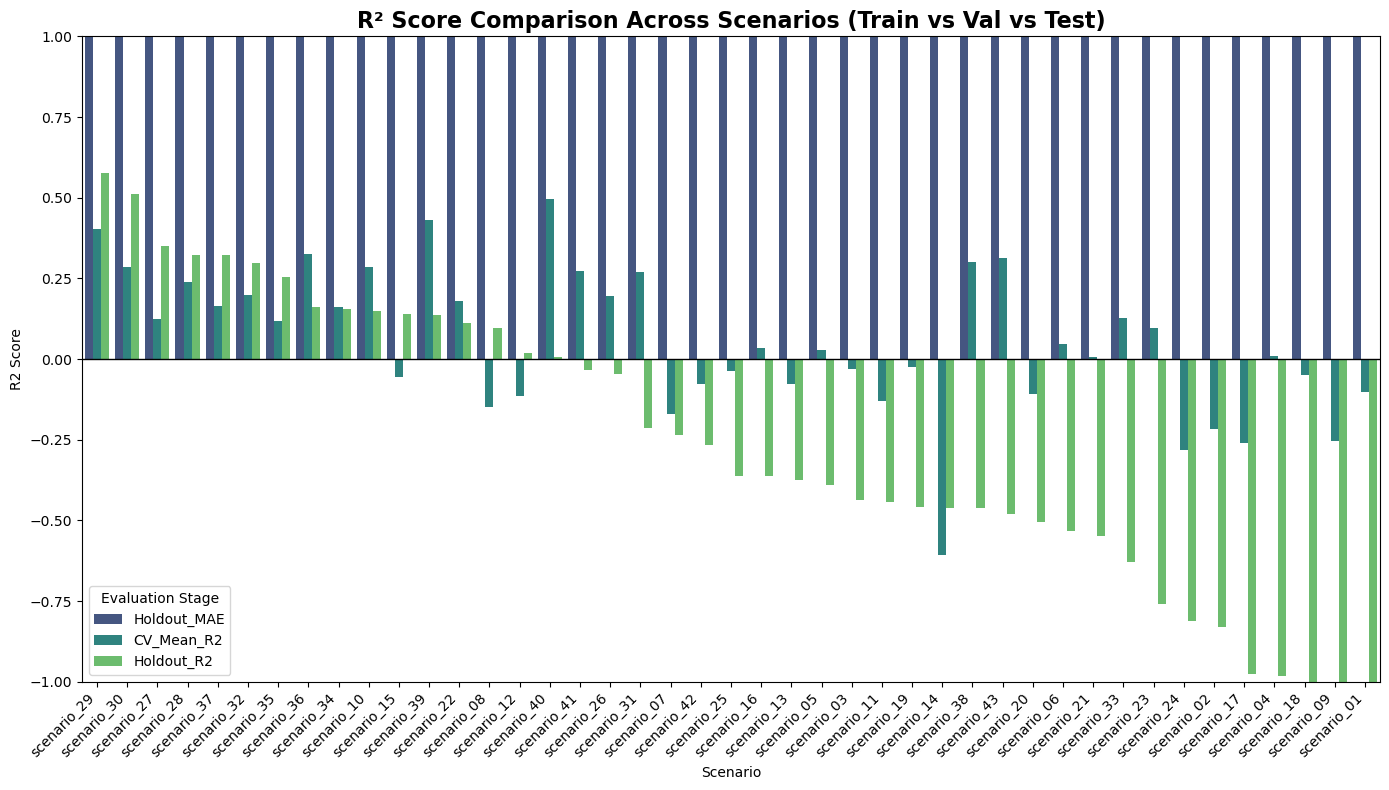

In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error)
import os
import random
import joblib
import shutil  # Required for deleting old models
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings


# ==========================================
# 1. SETUP & REPRODUCIBILITY
# ==========================================
def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.config.experimental.enable_op_determinism()

SEED = 42
seed_everything(SEED)
BASE_SAVE_DIR = "SOC_Hybrid_MViT-Qwen_Models_1x1"
PLOT_SAVE_DIR = "SOC_Hybrid_Visualizations_1x1"

if not os.path.exists(PLOT_SAVE_DIR):
    os.makedirs(PLOT_SAVE_DIR)

# ==========================================
# 2. CUSTOM LAYERS
# ==========================================

@keras.utils.register_keras_serializable()
class RMSNorm(layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon
    def build(self, input_shape):
        self.scale = self.add_weight(name='scale', shape=(input_shape[-1],), initializer='ones', trainable=True)
        super().build(input_shape)
    def call(self, x):
        mean_square = tf.reduce_mean(tf.square(x), axis=-1, keepdims=True)
        return x * tf.math.rsqrt(mean_square + self.epsilon) * self.scale
    def get_config(self):
        return {**super().get_config(), "epsilon": self.epsilon}

@keras.utils.register_keras_serializable()
class SwiGLU(layers.Layer):
    def __init__(self, hidden_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout_rate
    def build(self, input_shape):
        self.w_gate = layers.Dense(self.hidden_dim, use_bias=False)
        self.w_val = layers.Dense(self.hidden_dim, use_bias=False)
        self.w_out = layers.Dense(input_shape[-1], use_bias=False)
        self.dropout = layers.Dropout(self.dropout_rate)
    def call(self, x):
        return self.dropout(self.w_out(tf.nn.silu(self.w_gate(x)) * self.w_val(x)))
    def get_config(self):
        return {**super().get_config(), "hidden_dim": self.hidden_dim, "dropout_rate": self.dropout_rate}

@keras.utils.register_keras_serializable()
class RotaryEmbedding(layers.Layer):
    def __init__(self, dim, max_len=1024, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.max_len = max_len
    def build(self, input_shape):
        inv_freq = 1.0 / (10000 ** (tf.range(0, self.dim, 2, dtype=tf.float32) / self.dim))
        t = tf.range(self.max_len, dtype=tf.float32)
        freqs = tf.einsum('i,j->ij', t, inv_freq)
        self.cos_cached = tf.Variable(tf.cos(freqs), trainable=False, dtype=tf.float32)
        self.sin_cached = tf.Variable(tf.sin(freqs), trainable=False, dtype=tf.float32)
        super().build(input_shape)
    def call(self, x):
        seq_len = tf.shape(x)[1]
        cos, sin = self.cos_cached[:seq_len, :], self.sin_cached[:seq_len, :]
        x_rot, x_pass = x[..., :self.dim], x[..., self.dim:]
        x1, x2 = x_rot[..., :self.dim // 2], x_rot[..., self.dim // 2:]
        return tf.concat([x1 * cos - x2 * sin, x1 * sin + x2 * cos, x_pass], axis=-1)
    def get_config(self):
        return {**super().get_config(), "dim": self.dim, "max_len": self.max_len}

# ==========================================
# 3. HYBRID MODEL BUILDER
# ==========================================

def build_hybrid_mvit_qwen(input_dim, num_patches=8, embed_dim=128, dropout=0.1):
    inputs = layers.Input(shape=(input_dim,), name="input_features")

    # --- Branch A: MViT ---
    x_mvit = layers.Reshape((num_patches, embed_dim))(layers.Dense(num_patches * embed_dim)(inputs))
    pos_emb = layers.Embedding(input_dim=num_patches, output_dim=embed_dim)(tf.range(0, num_patches))
    x_mvit = x_mvit + pos_emb

    for _ in range(2):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x_mvit)
        x_mvit = layers.Add()([x_mvit, layers.MultiHeadAttention(num_heads=4, key_dim=embed_dim)(x1, x1)])
        x2 = layers.LayerNormalization(epsilon=1e-6)(x_mvit)
        mlp = layers.Dropout(dropout)(layers.Dense(embed_dim*2, activation="gelu")(x2))
        x_mvit = layers.Add()([x_mvit, layers.Dense(embed_dim)(mlp)])
    out_mvit = layers.LayerNormalization()(layers.GlobalAveragePooling1D()(x_mvit))

    # --- Branch B: Qwen ---
    x_qwen = layers.Dropout(dropout)(layers.Reshape((num_patches, embed_dim))(layers.Dense(num_patches * embed_dim)(inputs)))
    rope = RotaryEmbedding(embed_dim // 4)

    for _ in range(2):
        x_norm = RMSNorm()(x_qwen)
        x_rot = rope(x_norm)
        x_qwen = layers.Add()([x_qwen, layers.MultiHeadAttention(num_heads=4, key_dim=embed_dim, dropout=dropout)(x_rot, x_rot)])
        x_norm = RMSNorm()(x_qwen)
        x_qwen = layers.Add()([x_qwen, SwiGLU(hidden_dim=embed_dim*2, dropout_rate=dropout)(x_norm)])
    out_qwen = layers.GlobalAveragePooling1D()(RMSNorm()(x_qwen))

    # --- Fusion ---
    gate = layers.Dense(embed_dim, activation='sigmoid')(layers.Concatenate()([out_mvit, out_qwen]))
    fused = layers.Add()([layers.Multiply()([out_mvit, gate]), layers.Multiply()([out_qwen, 1 - gate])])

    outputs = layers.Dense(1, activation='linear')(layers.Dropout(0.1)(layers.Dense(64, activation='relu')(fused)))
    return keras.Model(inputs=inputs, outputs=outputs, name="Hybrid_MViT_Qwen")

# ==========================================
# 4. UTILS & TOP-5 MANAGER
# ==========================================

class TopModelManager:
    """Manages the Top-5 models on disk based on RMSE (asc) and R2 (desc)."""
    def __init__(self, save_dir=BASE_SAVE_DIR, max_models=5):
        self.save_dir = save_dir
        self.max_models = max_models
        self.top_models = []
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

    def process_candidate(self, model, scaler, scenario, rmse, r2, cv_r2):
        candidate = {
            'rmse': rmse, 'r2': r2, 'scenario': scenario, 'cv_r2': cv_r2,
            'folder_name': f"{scenario}_RMSE_{rmse:.4f}_R2_{r2:.4f}_CV-R2_{cv_r2:.4f}"
        }
        self.top_models.sort(key=lambda x: (x['rmse'], -x['r2']))

        should_save = False
        if len(self.top_models) < self.max_models:
            should_save = True
        else:
            worst_best = self.top_models[-1]
            if (rmse < worst_best['rmse']) or (rmse == worst_best['rmse'] and r2 > worst_best['r2']):
                should_save = True

        if should_save:
            full_path = os.path.join(self.save_dir, candidate['folder_name'])
            os.makedirs(full_path, exist_ok=True)
            model.save(os.path.join(full_path, "model.keras"))
            joblib.dump(scaler, os.path.join(full_path, "scaler.pkl"))
            print(f"   ✅ [SAVED] Top-5 Candidate: {full_path}")
            
            candidate['path'] = full_path
            self.top_models.append(candidate)
            self.top_models.sort(key=lambda x: (x['rmse'], -x['r2']))
            
            if len(self.top_models) > self.max_models:
                to_remove = self.top_models.pop()
                print(f"   🗑️ [PRUNING] Removing displaced model: {to_remove['folder_name']}")
                if os.path.exists(to_remove['path']):
                    shutil.rmtree(to_remove['path'])
        else:
            print(f"   [SKIP] Model did not qualify for Top-5.")

def predict_from_loaded(scenario_folder_name, new_data, feature_cols, base_dir=BASE_SAVE_DIR):
    path = os.path.join(base_dir, scenario_folder_name)
    model_path = os.path.join(path, "model.keras")
    scaler_path = os.path.join(path, "scaler.pkl")
    
    if not os.path.exists(model_path): return None

    custom_objects = {'RMSNorm': RMSNorm, 'SwiGLU': SwiGLU, 'RotaryEmbedding': RotaryEmbedding}
    model = keras.models.load_model(model_path, custom_objects=custom_objects)
    scaler = joblib.load(scaler_path)

    if isinstance(new_data, pd.DataFrame):
        X = new_data[feature_cols].values
    else:
        X = new_data 

    X_scaled = scaler.transform(X)
    y_pred = np.expm1(model.predict(X_scaled, verbose=0).flatten())
    return np.maximum(y_pred, 0)

# ==========================================
# 5. TRAINING HELPERS & VISUALIZATIONS
# ==========================================

def clip_outliers(X_train, X_test=None, lower_percentile=1, upper_percentile=99):
    X_train_clipped = X_train.copy()
    X_test_clipped = X_test.copy() if X_test is not None else None
    
    for col in X_train.columns:
        lower = X_train[col].quantile(lower_percentile / 100)
        upper = X_train[col].quantile(upper_percentile / 100)
        
        X_train_clipped[col] = X_train_clipped[col].clip(lower, upper)
        if X_test_clipped is not None:
            X_test_clipped[col] = X_test_clipped[col].clip(lower, upper)
            
    return X_train_clipped, X_test_clipped

def get_lr_schedule(total_steps, lr_max=0.001):
    return keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=lr_max, decay_steps=total_steps, alpha=0.01
    )

def plot_scenario_performance(scenario, y_train, pred_train, y_test, pred_test, history):
    """Generates and saves full parity plots, residual plots, and training history."""
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f"Model Performance: {scenario}", fontsize=18, weight='bold')
    
    # 1. Parity Plot: Train vs Pred
    ax1 = plt.subplot(2, 3, 1)
    sns.scatterplot(x=y_train, y=pred_train, alpha=0.5, color='blue', ax=ax1)
    ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2)
    ax1.set_title(f"Train: Actual vs Predicted (R²={r2_score(y_train, pred_train):.3f})")
    ax1.set_xlabel("Actual SOC")
    ax1.set_ylabel("Predicted SOC")
    
    # 2. Parity Plot: Test vs Pred
    ax2 = plt.subplot(2, 3, 2)
    sns.scatterplot(x=y_test, y=pred_test, alpha=0.5, color='orange', ax=ax2)
    ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    ax2.set_title(f"Test: Actual vs Predicted (R²={r2_score(y_test, pred_test):.3f})")
    ax2.set_xlabel("Actual SOC")
    ax2.set_ylabel("Predicted SOC")

    # 3. Training History (Loss)
    ax3 = plt.subplot(2, 3, 3)
    ax3.plot(history.history['loss'], label='Train Huber Loss', color='blue')
    # Validation loss isn't logged in final training loop by default unless we pass validation data. 
    # Left as strictly training loss for the final epoch curve.
    ax3.set_title("Final Model Training History")
    ax3.set_xlabel("Epochs")
    ax3.set_ylabel("Loss")
    ax3.legend()

    # 4. Residuals: Train
    ax4 = plt.subplot(2, 3, 4)
    train_residuals = y_train - pred_train
    sns.histplot(train_residuals, kde=True, color='blue', ax=ax4)
    ax4.axvline(0, color='k', linestyle='--')
    ax4.set_title("Train Residuals Distribution")

    # 5. Residuals: Test
    ax5 = plt.subplot(2, 3, 5)
    test_residuals = y_test - pred_test
    sns.histplot(test_residuals, kde=True, color='orange', ax=ax5)
    ax5.axvline(0, color='k', linestyle='--')
    ax5.set_title("Test Residuals Distribution")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    plot_path = os.path.join(PLOT_SAVE_DIR, f"{scenario}_performance_plots.png")
    plt.savefig(plot_path, dpi=300)
    plt.close()
    print(f"   📊 [SAVED] Scenario Plot: {plot_path}")


# ==========================================
# 5.5 SHAP EXPLAINABILITY VISUALIZATIONS
# ==========================================

def generate_shap_visualizations(model, scaler, X_train_raw, X_test_raw, feature_cols, scenario_name, save_dir=PLOT_SAVE_DIR):
    """
    Generates comprehensive SHAP plots (Bar, Beeswarm, Waterfall) for the custom hybrid model.
    Uses KernelExplainer to bypass gradient graph issues with custom TF layers.
    """
    print(f"\n   🧠 Generating SHAP visualizations for {scenario_name}...")
    
    # Ensure SHAP save directory exists
    shap_dir = os.path.join(save_dir, f"{scenario_name}_SHAP")
    os.makedirs(shap_dir, exist_ok=True)

    # 1. Prepare Data (DYNAMIC SIZING FIX)
    n_train_samples = len(X_train_raw)
    if n_train_samples > 50:
        # If we have a lot of data, cluster it down to 50 for speed
        X_train_summary = shap.kmeans(X_train_raw[feature_cols], 50) 
    else:
        # If the dataset is small, just use the raw data as the background
        X_train_summary = X_train_raw[feature_cols]
    
    # Subsample test data (up to 100 rows) for the explanation
    test_sample_size = min(100, len(X_test_raw))
    # If the test set is exactly the size we need or smaller, no need to randomly sample
    if len(X_test_raw) <= test_sample_size:
        X_test_sample = X_test_raw[feature_cols]
    else:
        X_test_sample = X_test_raw[feature_cols].sample(n=test_sample_size, random_state=SEED)
    
    # # 2. Define Prediction Wrapper
    # def predict_wrapper(X_array):
    #     if len(X_array.shape) == 1:
    #         X_array = X_array.reshape(1, -1)
    #     X_scaled = scaler.transform(X_array)
    #     return model.predict(X_scaled, verbose=0).flatten()
    
    # 2. Define Prediction Wrapper
    def predict_wrapper(X_array):
        # Convert to 2D if SHAP passes a 1D array
        if len(X_array.shape) == 1:
            X_array = X_array.reshape(1, -1)
            
        # --- THE FIX: Convert the raw array back into a DataFrame with column names ---
        X_df = pd.DataFrame(X_array, columns=feature_cols)
        
        # Now the scaler will recognize the feature names!
        X_scaled = scaler.transform(X_df)
        
        return model.predict(X_scaled, verbose=0).flatten()
        
    # 3. Initialize Explainer & Calculate Values
    explainer = shap.KernelExplainer(predict_wrapper, X_train_summary)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # Calculate SHAP values
        shap_values_raw = explainer.shap_values(X_test_sample, nsamples=200)
        
    # Handle SHAP return type inconsistencies
    shap_values = shap_values_raw[0] if isinstance(shap_values_raw, list) else shap_values_raw

    # Create an Explanation object
    exp = shap.Explanation(values=shap_values, 
                           base_values=explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value, 
                           data=X_test_sample.values, 
                           feature_names=feature_cols)

    # --- Plot 1: Summary Bar Plot ---
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
    plt.title(f"SHAP Global Feature Importance - {scenario_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(shap_dir, f"{scenario_name}_shap_bar.png"), dpi=300, bbox_inches='tight')
    plt.close()

    # --- Plot 2: Summary Beeswarm Plot ---
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_sample, show=False)
    plt.title(f"SHAP Beeswarm Summary - {scenario_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(shap_dir, f"{scenario_name}_shap_beeswarm.png"), dpi=300, bbox_inches='tight')
    plt.close()

    # --- Plot 3: Waterfall Plot ---
    plt.figure(figsize=(10, 8))
    shap.waterfall_plot(exp[0], show=False)
    plt.title(f"SHAP Waterfall (Local Prediction Sample 0) - {scenario_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(shap_dir, f"{scenario_name}_shap_waterfall.png"), dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"   ✅ [SAVED] SHAP visualizations saved to: {shap_dir}")

# ==========================================
# 6. MAIN EXECUTION
# ==========================================

# Assuming 'scenarios', 'X_train', 'y_train', 'X_test', 'y_test' exist
if 'scenarios' not in locals():
    print("WARNING: 'scenarios' dictionary not defined.")
    scenarios = {} 

hybrid_results = []
top_saver = TopModelManager(max_models=5)
print("Starting Hybrid Model Training (Top-5 Saved)...")

kf = KFold(n_splits=3, shuffle=True, random_state=SEED)

for scenario_name, feature_cols in scenarios.items():
    feature_cols = list(set(feature_cols))
    valid_cols = [c for c in feature_cols if c in X_train.columns]
    
    if not valid_cols: continue

    X_train_sub = X_train[valid_cols].copy()
    X_test_sub = X_test[valid_cols].copy() 
    
    train_indices = X_train_sub.dropna().index.intersection(y_train.dropna().index)
    X = X_train_sub.loc[train_indices].reset_index(drop=True)
    y = y_train.loc[train_indices].reset_index(drop=True)

    if len(X) < 10: continue

    print(f"\n--- Scenario: {scenario_name} (Feats: {len(valid_cols)}, Samples: {len(X)}) ---")

    fold_train_r2, fold_val_r2, fold_rmse = [], [], []

    # --- CROSS VALIDATION LOOP ---
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_tr_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        X_tr_clip, X_val_clip = clip_outliers(X_tr_fold, X_val_fold)
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr_clip)
        X_val_sc = scaler.transform(X_val_clip)

        y_tr_log = np.log1p(y_tr_fold)
        y_val_log = np.log1p(y_val_fold)

        input_dim = X_tr_sc.shape[1]
        n_patches = 8 if input_dim > 15 else 4
        steps_per_epoch = max(1, len(X_tr_sc) // 32)
        total_steps = max(1, 1500 * steps_per_epoch)
        
        model = build_hybrid_mvit_qwen(input_dim, num_patches=n_patches, embed_dim=128, dropout=0.15)
        model.compile(
            loss=keras.losses.Huber(delta=1.0), 
            optimizer=keras.optimizers.AdamW(learning_rate=get_lr_schedule(total_steps), weight_decay=0.02),
            metrics=['mae']
        )

        model.fit(
            X_tr_sc, y_tr_log,
            validation_data=(X_val_sc, y_val_log), 
            # epochs= 4000, # | r2 0.
            # epochs= 3500, # | r2 0.4
            # epochs= 3000, # | r2 0.3
            # epochs= 2500, # r2 0.265, -0.24, |0.39
            # epochs= 2000, # r2 0.18 | 0.02
            # epochs= 1800, # r2 0.05 || 0.20, 0.19, 0.3
            epochs= 1500, # r2 0.27, 0.11, 0.16, 0.22, -0.15, | 0.02 || 0.36, 0.33, 0.3, 0.54, 0.4
            # epochs= 1300, # r2 0.04 || 0.23
            # epochs= 1200, # r2 0.27, 0.11, 0.22, 0.06, 0.03, 0.05, 0.28, | 0.23 || 0.4, 0.2, -0.3
            # epochs= 1000, # | r2 -0.00
            # epochs= 900, # r2 -0.03,
            # epochs= 800, # r2 0.049
            # epochs= 700, # r2 -0.03,            
            # epochs= 600, # r2 0.16
            # epochs= 500, # r2 0.16, 0.2
            # epochs= 550, # r2 -0.03, 0.2
            # epochs= 400, # r2 0.16
            # epochs= 300, # r2 0.16
            # epochs= 250, # r2 0.11
            # epochs= 200, # r2 0.10
            batch_size=32,
            callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
            verbose=0
        )

        # Eval Train
        y_tr_pred = np.maximum(np.expm1(model.predict(X_tr_sc, verbose=0).flatten()), 0)
        fold_train_r2.append(r2_score(y_tr_fold, y_tr_pred))

        # Eval Val
        y_val_pred = np.maximum(np.expm1(model.predict(X_val_sc, verbose=0).flatten()), 0)
        fold_val_r2.append(r2_score(y_val_fold, y_val_pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_val_fold, y_val_pred)))
        
        print(f"   Fold {fold+1} | Train R2: {fold_train_r2[-1]:.4f} | Val R2: {fold_val_r2[-1]:.4f}")

    # --- FINAL FULL TRAINING & TOP-5 SAVING ---
    print(f"   >> Retraining full model for evaluation...")
    X_full_clip, X_test_clip = clip_outliers(X, X_test_sub)
    final_scaler = StandardScaler()
    X_full_sc = final_scaler.fit_transform(X_full_clip)
    X_test_sc = final_scaler.transform(X_test_clip) 
    y_full_log = np.log1p(y)

    final_model = build_hybrid_mvit_qwen(input_dim, num_patches=n_patches, embed_dim=128)
    steps_per_epoch_final = max(1, len(X_full_sc) // 32)
    total_steps_final = max(1, 2000 * steps_per_epoch_final)
    
    final_model.compile(
        loss=keras.losses.Huber(delta=1.0),
        optimizer=keras.optimizers.AdamW(learning_rate=get_lr_schedule(total_steps_final)),
        metrics=['mae']
    )

    history = final_model.fit(X_full_sc, y_full_log, 
                              # epochs= 3200, #r2 | 0.
                              # epochs= 3000, #r2 0.453 | 0.49
                              # epochs= 3500, #r2 0.45 | 0.51
                              # epochs= 3800, #r2 0.53, 0.46 | 0.55 || 0.54
                              # epochs= 3900, #r2 0.50 
                              # epochs= 4000, #r2 0.58, 0.55, 0.455, 0.47, 0.49, 0.52, 0.55, 0.58, 0.56, | 0.46 || 0.54, 0.5
                              epochs= 4100, #r2 0.50 || 0.62, 0.57, 0.60, 0.49. 0.54, 0.57
                              # epochs= 4200, #r2 0.516, 0.518, 0.46, 0.55, | 0.48  || 0.61 , 0.52, 
                              # epochs= 4300, #r2 0.43
                              # epochs= 4500, #r2 0.49, | 0.47 || 0.59
                              # epochs= 5000, #r2 0.47 | 0.46
                              # epochs= 6000, # | r2 0.
                              # epochs= 7000, #r2 0.47 | 0.41
                              # epochs= 8000, #r2 0.48, 0.47
                              # epochs= 9000, #r2 0.45
                              # epochs= 10000, #r2 0.517, 0.501
                              batch_size=32, verbose=0)

    # Predict on Train & Holdout Test
    # y_full_pred = np.maximum(np.expm1(final_model.predict(X_full_sc, verbose=0).flatten()), 0)
    y_pred_h = np.maximum(np.expm1(final_model.predict(X_test_sc, verbose=0).flatten()), 0)
 
    # Calculate Metrics
    r2_final = r2_score(y_test, y_pred_h)
    rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_h))
    mae_final = mean_absolute_error(y_test, y_pred_h)
    mape_final = mean_absolute_percentage_error(y_test, y_pred_h)
    cv_mean_r2 = np.mean(fold_val_r2)
    cv_min_r2 = np.min(fold_val_r2)
    cv_max_r2 = np.max(fold_val_r2)

    # --- TOP-5 SAVER LOGIC ---
    # Instead of unconditional saving, we let the manager decide
    top_saver.process_candidate(
        final_model, final_scaler, scenario_name, 
        rmse_final, r2_final, cv_mean_r2
    )

    hybrid_results.append({
        'Scenario': scenario_name,
        'CV_Mean_R2': cv_mean_r2,
        'CV_Min_R2': cv_min_r2,
        'CV_Max_R2': cv_max_r2,
        'CV_Std_R2': np.std(fold_val_r2),
        'CV_Mean_RMSE': np.mean(fold_rmse),
        'Holdout_R2': r2_final,
        'Holdout_RMSE': rmse_final,
        'Holdout_MAE': mae_final,
        'Holdout_MAPE': mape_final
    })

    print(f"   [Result] CV_Mean_R2: {cv_mean_r2:.4f} | Holdout_R2: {r2_final:.4f} | Holdout_RMSE: {rmse_final:.4f}")


    # ==========================================
    # ---> ADD THE SHAP CALL HERE <---
    # ==========================================
    # We pass the unclipped/unscaled data because our wrapper handles the scaling,
    # ensuring the SHAP plots show the actual real-world feature values on the axes.
    generate_shap_visualizations(
        model=final_model, 
        scaler=final_scaler, 
        X_train_raw=X, 
        X_test_raw=X_test_sub, 
        feature_cols=valid_cols, 
        scenario_name=scenario_name
    )
    
# ==========================================
# 7. RESULTS & OVERALL VISUALIZATION
# ==========================================
if hybrid_results:
    results_df = pd.DataFrame(hybrid_results).sort_values(by='Holdout_R2', ascending=False)
    print("\n" + "="*80)
    print("HYBRID MViT + QWEN RESULTS (WITH TRAIN/VAL/TEST R2)")
    print("="*80)
    print(results_df[['Scenario', 'CV_Mean_R2', 'Holdout_R2', 'Holdout_RMSE', 'Holdout_MAE', 'Holdout_MAPE']])
    results_df.to_csv('SOC_Hybrid_MViT-QWEN_1x1_Results_Local.csv', index=False)

    # Plot Overall Comparison Bar Chart
    plt.figure(figsize=(14, 8))
    
    plot_data = results_df.melt(
        id_vars=['Scenario'], 
        value_vars=['Holdout_MAE', 'CV_Mean_R2', 'Holdout_R2'],
        var_name='Metric', value_name='R2 Score'
    )
    
    sns.barplot(data=plot_data, x='Scenario', y='R2 Score', hue='Metric', palette='viridis')
    plt.title("R² Score Comparison Across Scenarios (Train vs Val vs Test)", fontsize=16, weight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(max(-1, plot_data['R2 Score'].min() - 0.1), 1.0) # Scale appropriately
    plt.axhline(0, color='black', linewidth=1)
    plt.legend(title='Evaluation Stage')
    plt.tight_layout()
    
    summary_plot_path = os.path.join(PLOT_SAVE_DIR, "Overall_R2_Comparison.png")
    plt.savefig(summary_plot_path, dpi=300)
    print(f"\n   📊 [SAVED] Summary Bar Chart: {summary_plot_path}")

# Best Model Prediction

In [6]:
# ==============================================================================
# SOC PREDICTION SCRIPT: HYBRID MViT-QWEN (SCENARIO 29) - CORRECTED ORDER
# ==============================================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib
from pathlib import Path
from sklearn.impute import SimpleImputer

# ------------------------------------------------------------------------------
# 1. CUSTOM LAYER DEFINITIONS (Required for Model Reconstruction)
# ------------------------------------------------------------------------------
@keras.utils.register_keras_serializable()
class RMSNorm(layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        self.scale = self.add_weight(name='scale', shape=(input_shape[-1],), 
                                     initializer='ones', trainable=True)
        super().build(input_shape)

    def call(self, x):
        mean_square = tf.reduce_mean(tf.square(x), axis=-1, keepdims=True)
        return x * tf.math.rsqrt(mean_square + self.epsilon) * self.scale

    def get_config(self):
        return {**super().get_config(), "epsilon": self.epsilon}

@keras.utils.register_keras_serializable()
class SwiGLU(layers.Layer):
    def __init__(self, hidden_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        self.w_gate = layers.Dense(self.hidden_dim, use_bias=False)
        self.w_val = layers.Dense(self.hidden_dim, use_bias=False)
        self.w_out = layers.Dense(input_shape[-1], use_bias=False)
        self.dropout = layers.Dropout(self.dropout_rate)
        super().build(input_shape)

    def call(self, x):
        return self.dropout(self.w_out(tf.nn.silu(self.w_gate(x)) * self.w_val(x)))

    def get_config(self):
        return {**super().get_config(), "hidden_dim": self.hidden_dim, "dropout_rate": self.dropout_rate}

@keras.utils.register_keras_serializable()
class RotaryEmbedding(layers.Layer):
    def __init__(self, dim, max_len=1024, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.max_len = max_len

    def build(self, input_shape):
        inv_freq = 1.0 / (10000 ** (tf.range(0, self.dim, 2, dtype=tf.float32) / self.dim))
        t = tf.range(self.max_len, dtype=tf.float32)
        freqs = tf.einsum('i,j->ij', t, inv_freq)
        self.cos_cached = tf.Variable(tf.cos(freqs), trainable=False, dtype=tf.float32)
        self.sin_cached = tf.Variable(tf.sin(freqs), trainable=False, dtype=tf.float32)
        super().build(input_shape)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        cos, sin = self.cos_cached[:seq_len, :], self.sin_cached[:seq_len, :]
        x_rot, x_pass = x[..., :self.dim], x[..., self.dim:]
        x1, x2 = x_rot[..., :self.dim // 2], x_rot[..., self.dim // 2:]
        return tf.concat([x1 * cos - x2 * sin, x1 * sin + x2 * cos, x_pass], axis=-1)

    def get_config(self):
        return {**super().get_config(), "dim": self.dim, "max_len": self.max_len}

# ------------------------------------------------------------------------------
# 2. PREDICTION HELPER FUNCTION
# ------------------------------------------------------------------------------
def predict_from_loaded(model_folder_path, new_data, feature_cols):
    """Loads model/scaler from the given absolute path and predicts."""
    base_path = Path(model_folder_path)
    model_path = base_path / "model.keras"
    scaler_path = base_path / "scaler.pkl"
    
    # Fallback to current directory just in case
    if not model_path.exists(): model_path = Path("model.keras")
    if not scaler_path.exists(): scaler_path = Path("scaler.pkl")

    if not model_path.exists() or not scaler_path.exists(): 
        raise FileNotFoundError(f"❌ Error: Model or Scaler not found at {base_path} or current directory.")

    custom_objects = {
        'RMSNorm': RMSNorm, 
        'SwiGLU': SwiGLU, 
        'RotaryEmbedding': RotaryEmbedding
    }
    
    try:
        model = keras.models.load_model(model_path, custom_objects=custom_objects)
        scaler = joblib.load(scaler_path)
    except Exception as e:
        raise RuntimeError(f"❌ Error loading model or scaler files: {e}")

    # CRITICAL: Reorder columns in df to match the exact order expected by the scaler
    X_input = new_data[feature_cols] 
    
    # Scikit-learn expects feature names to exactly match training if provided as a dataframe
    X_scaled = scaler.transform(X_input)
    
    # Predict and reverse log1p
    raw_preds = model.predict(X_scaled, verbose=0).flatten()
    y_pred = np.expm1(raw_preds)
    
    return np.maximum(y_pred, 0)

# ------------------------------------------------------------------------------
# 3. MAIN EXECUTION BLOCK
# ------------------------------------------------------------------------------
if __name__ == "__main__":
    
    # --- FIXED: THIS ORDER NOW MATCHES THE internal structure of your scaler.pkl EXACTLY ---
    scenarios = {
        "29_scenario": [
            'S1_VV_ent', 'B8A_shade', 'B2_shade', 'S1_VV_idm', 'B1_savg', 
            'B1', 'B11_corr', 'B4_sent', 'B4_var', 'B3'
        ]
    }

    # Configuration Parameters (Fixed Paths so they don't overwrite each other)
    csv_file_path = Path(r"C:\Users\ASUS\Downloads\VCS_1764_SOC_2024_scenario_29_1x1_clean.csv")
    BEST_MODEL_FOLDER = Path(r"C:\Users\ASUS\Downloads\scenario_29_RMSE_196.1826_R2_0.6090_CV-R2_0.3691_1x1")
    OUTPUT_FILE = Path(r"C:\Users\ASUS\Downloads\Scenario_29_Final_Predictions.csv")
    
    SCENARIO_KEY = "29_scenario"
    COORD_COLS = ['latitude', 'longitude']

    if csv_file_path.exists():
        df_new = pd.read_csv(csv_file_path)
        feat_cols = scenarios[SCENARIO_KEY]
        
        # 3.1 Verify Columns
        missing = [c for c in feat_cols + COORD_COLS if c not in df_new.columns]
        if missing:
            print(f"❌ Missing columns in CSV: {missing}")
        else:
            print(f"📂 Processing {len(df_new)} rows...")
            
            # 3.2 Impute Missing Values (NaNs)
            imputer = SimpleImputer(strategy='mean')
            df_processed = df_new.copy()
            df_processed[feat_cols] = imputer.fit_transform(df_new[feat_cols])

            # 3.3 Execute Prediction
            try:
                y_pred = predict_from_loaded(BEST_MODEL_FOLDER, df_processed, feat_cols)
                
                # 3.4 Create Export File
                export_df = df_new[COORD_COLS].copy()
                export_df['Predicted_SOC'] = y_pred
                
                export_df.to_csv(OUTPUT_FILE, index=False)
                
                print(f"✅ Success! Results saved to: {OUTPUT_FILE}")
                print("\n--- Summary Stats ---")
                print(export_df['Predicted_SOC'].describe())

            except Exception as e:
                print(e)
    else:
        print(f"❌ Error: Could not find CSV at {csv_file_path}")

📂 Processing 218229 rows...
✅ Success! Results saved to: C:\Users\ASUS\Downloads\Scenario_29_Final_Predictions.csv

--- Summary Stats ---
count    218229.000000
mean        675.973511
std         184.735519
min           0.000000
25%         590.700073
50%         678.432495
75%         777.335327
max        1413.929077
Name: Predicted_SOC, dtype: float64


# End